# 대용량 데이터, 어떻게 처리할까?

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🚀 대용량 데이터, 어떻게 처리할까? — pandas의 한계, 청크, 그리고 Polars

### — 메모리에 다 안 올라가는 데이터 앞에서 분석가는 무엇을 선택하는가 —

---

## 📋 학습 목표

이 자습서를 마치면 여러분은 다음을 할 수 있습니다.

1. pandas가 메모리 위에서 어떻게 동작하고 왜 큰 데이터에서 멈추는지 설명할 수 있습니다.
2. dtype 최적화·청크 처리·Polars의 lazy evaluation이 각각 어떤 원리로 메모리·속도를 개선하는지 비교할 수 있습니다.
3. pandas와 Polars의 구조 차이를 알고, 데이터 크기·팀 환경·요구사항에 따라 어떤 도구를 쓸지 고를 수 있습니다.
4. 같은 데이터셋을 dtype 최적화·청크·Polars로 처리해보고 메모리·속도 차이를 직접 측정할 수 있습니다.
5. 선택한 전략으로 대용량 데이터 처리 파이프라인을 작성할 수 있습니다.
6. 측정 결과를 근거로 "왜 이 도구를 골랐는가"를 한 문단으로 정당화할 수 있습니다.
7. 코드를 짜기 전에 데이터 크기·요구사항·팀 환경부터 먼저 살피는 습관을 들일 수 있습니다.

> 💡 위 목록을 천천히 읽고, 지금 내가 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해보세요. 자습서를 다 마친 뒤 다시 돌아와 비교하면 여러분의 성장이 눈에 보일 거예요.

## 📚 목차

| Part | 내용 | 핵심 질문 |
| --- | --- | --- |
| Part 0 | 분석 상황과 학습 지도 | 데이터가 갑자기 커졌습니다. 우리는 무엇을 알아야 할까요? |
| Part 1 | pandas는 어디서 멈추는가 | pandas는 왜 큰 데이터를 못 버틸까요? |
| Part 2 | dtype 최적화 — 메모리 절약의 첫 단추 | 같은 값을 더 작은 그릇에 담을 수는 없을까요? |
| Part 3 | 청크 처리 — 한 번에 못 올리면 나눠서 | 메모리에 다 안 올라가는 파일을 어떻게 분석할까요? |
| Part 4 | Polars 입문 — 새로운 무대의 등장 | Polars는 pandas와 무엇이 다를까요? |
| Part 5 | Lazy evaluation — 계획부터 세우는 실행 | 같은 코드인데 왜 Polars가 더 빠를까요? |
| Part 6 | pandas vs Polars — 직접 측정해보기 | 어느 쪽이 더 빠른지 숫자로 확인해봅시다. |
| Part 7 | 도구 선택 의사결정 | 언제 무엇을 쓸지 어떻게 고를까요? |
| 종합 실습 | 대용량 로그 처리 마무리 | 측정 결과로 선택을 정당화할 수 있을까요? |
| 정리 | 핵심 요약 · 다음 시간 | 처리한 데이터를 어떻게 검증하고 전달할까요? |

## 분석 상황과 학습 지도

# 0. 분석 상황과 학습 지도

## 지난 시간에는 무엇을 했나요?

바로 전 시간에는 **수작업 정제를 함수와 파이프라인으로 자동화**하는 방법을 배웠습니다. `apply`·`map`·벡터화의 성능 차이를 비교하고, 범주형 인코딩과 수치 스케일링을 거쳐 method chaining과 `.pipe()`로 재사용 가능한 전처리 파이프라인을 만들었습니다.

즉, 여러분은 "한 번 짜면 다음에도 쓸 수 있는" 전처리 흐름을 손에 쥔 상태입니다. 그런데 그 파이프라인이 **수십만, 수백만 줄짜리 파일** 앞에서도 똑같이 잘 돌아갈까요? 오늘 우리는 그 질문에 답합니다.

## 오늘의 여정

오늘은 분석가가 마주하는 흔한 벽 하나를 정면으로 다룹니다. **"파일이 메모리에 안 올라가요."** 이 문장에서 출발해, pandas의 한계가 어디서 시작되는지를 보고, 그것을 우회하는 세 가지 길(dtype 최적화 / 청크 처리 / Polars)을 차례로 익힙니다. 마지막에는 직접 측정한 숫자를 근거로 도구를 고르는 의사결정까지 가봅니다.

```text
[Part 1] pandas는 어디서 멈추는가  →  한계의 정체
   ↓
[Part 2] dtype 최적화              →  같은 값, 더 작은 그릇
   ↓
[Part 3] 청크 처리                  →  나눠서 읽고 합치기
   ↓
[Part 4] Polars 입문                →  새로운 무대
   ↓
[Part 5] Lazy evaluation            →  계획부터 세우는 실행
   ↓
[Part 6] pandas vs Polars 측정      →  숫자로 비교하기
   ↓
[Part 7] 도구 선택 의사결정         →  상황에 맞는 선택
   ↓
[종합 실습] 대용량 로그 처리 마무리
```

## 이 자습서 사용법

이 노트북은 **혼자서도 끝까지 학습할 수 있도록** 만들었습니다. 다음 네 박자로 진행하세요.

- 📖 **읽고** — 개념 설명을 천천히 읽습니다.
- 💻 **실행하고** — 코드 셀을 위에서부터 순서대로 실행합니다. (단축키: `Shift + Enter`)
- ✏️ **고쳐보고** — "스스로 해보자! ✏️" 칸에서 코드를 직접 바꿔봅니다.
- 🤔 **답해보고** — 체크포인트 질문에 스스로 답해봅니다. 틀려도 괜찮습니다.

> ⚠ **주의:** 코드 셀은 반드시 **위에서부터 순서대로** 실행해야 합니다. 중간 셀을 건너뛰면 "앞에서 만든 변수가 없다"는 오류가 날 수 있어요. 오류는 잘못이 아니라 디버깅의 단서입니다. 천천히 읽어가세요.

## 환경 준비 — 라이브러리 불러오기

이 노트북은 `polars`를 사용합니다. 아직 설치돼 있지 않다면 아래 셀의 주석을 풀고 한 번만 실행하세요. 한글 폰트와 시드 고정도 함께 처리합니다.

In [1]:

import os
import gc
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("polars :", pl.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy  : 2.4.6
pandas : 3.0.3
polars : 1.42.1


## 오늘의 무대: 모두마켓 로그가 폭증한 어느 날

오늘도 무대는 **모두마켓** — 패션·뷰티·식품을 파는 가상 온라인 쇼핑몰입니다. 여러분은 이제 입사 일주일 차 데이터 분석가, 어느 정도 데이터를 다룰 줄 알게 되었습니다.

그런데 월요일 아침, 백엔드 엔지니어가 슬쩍 다가와 이렇게 말합니다.

> "주말 동안 마케팅 캠페인 효과로 트래픽이 평소의 10배가 됐어요. 웹 접속 로그가 한 50만 줄쯤 쌓였는데, 한번 분석해주실 수 있을까요?"

평소처럼 `pd.read_csv()`로 열어보려는 순간, 분석가의 머릿속에 질문이 떠오릅니다.

> "이 정도 크기면 평소처럼 다뤄도 될까? 혹시 메모리에 안 올라가면 어떻게 하지?"

오늘 자습서는 정확히 이 질문에서 출발합니다. **데이터 크기에 따라 분석가의 손은 달라져야 합니다.** 작은 데이터에서 잘 통하던 방법이 큰 데이터에서는 멈출 수 있고, 큰 데이터에서 쓰는 도구를 굳이 작은 데이터에 가져오면 오히려 느려질 수 있습니다.

> **🎯 오늘의 핵심**
> **"데이터 크기와 요구사항을 먼저 살핀 다음, 도구를 고른다."** 코드를 짜기 전에 도구 선택부터입니다. 그리고 그 선택의 근거는 *측정한 숫자*여야 합니다.

아래 셀을 실행하면 오늘 쓸 **모두마켓 데이터 세 종**을 만듭니다. 이번에는 일부러 **크게** 만듭니다 — `web_logs`는 50만 행, `orders`는 20만 행입니다. 메모장으로는 못 열 만한 양이지만 pandas로는 일단 열립니다. 우리는 이걸 다양한 방법으로 다뤄볼 거예요.

> **읽는 법:** `web_logs`는 50만 행입니다. 파일 크기는 100MB 안팎으로, 노트북 하나가 메모리에 올릴 수 있는 *상한선 근처*입니다. 오늘은 이 파일을 다양한 방법으로 읽고 다루며 도구별 차이를 직접 느껴봅니다.

이제 본격적으로 시작합시다. 가장 먼저 던질 질문은 단순합니다 — **"pandas는 정확히 어디서 멈추는가?"**

In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 오늘 쓸 데이터를 한 번에 준비합니다.
# (이번에는 일부러 크게 만듭니다. 메모리 한계가 슬슬 보이도록.)
# ─────────────────────────────────────────────
np.random.seed(42)

DATA_DIR = Path("./moodumarket_big")
DATA_DIR.mkdir(exist_ok=True)

# 1) 고객(customers) — 5만 명
n_customers = 50_000
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(6)}" for i in range(1, n_customers + 1)],
    "age": np.clip(np.random.normal(35, 9, n_customers).round(), 14, 80).astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(
        ["서울", "경기", "부산", "인천", "대구", "광주", "대전", "기타"], n_customers
    ),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.7, 0.25, 0.05]),
})

# 2) 상품(products) — 1천 종
n_products = 1_000
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(5)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(["패션", "뷰티", "식품", "가전", "도서"], n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders) — 20만 건
n_orders = 200_000
orders = pd.DataFrame({
    "order_id": np.arange(1, n_orders + 1),
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_id": np.random.choice(products["product_id"], n_orders),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n_orders),
    "amount": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_orders).astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.45, 0.55]),
    "order_date": pd.to_datetime("2025-01-01")
                  + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D"),
})

# 4) 웹 로그(web_logs) — 50만 건 (오늘의 주인공)
n_logs = 500_000
web_logs = pd.DataFrame({
    "log_id": np.arange(1, n_logs + 1),
    "ts": pd.to_datetime("2025-04-01")
          + pd.to_timedelta(np.random.randint(0, 86400 * 30, n_logs), unit="s"),
    "user_id": np.random.choice(customers["customer_id"], n_logs),
    "session_id": np.random.randint(1, 80_000, n_logs),
    "page": np.random.choice(
        ["home", "list", "detail", "cart", "checkout", "mypage", "search"],
        n_logs,
        p=[0.30, 0.25, 0.20, 0.10, 0.05, 0.05, 0.05],
    ),
    "device": np.random.choice(["mobile", "desktop", "tablet"], n_logs, p=[0.70, 0.25, 0.05]),
    "status_code": np.random.choice([200, 200, 200, 200, 304, 404, 500], n_logs),
    "response_ms": np.clip(np.random.gamma(2.0, 80, n_logs), 5, 5000).round().astype(int),
    "bytes_sent": np.random.randint(500, 200_000, n_logs),
})

# CSV로 저장해두면 청크 처리·Polars 입출력 비교 시 같은 파일을 함께 씁니다.
orders_csv = DATA_DIR / "orders.csv"
logs_csv = DATA_DIR / "web_logs.csv"
orders.to_csv(orders_csv, index=False)
web_logs.to_csv(logs_csv, index=False)

print("모두마켓 데이터 생성 완료")
print(f"  customers : {customers.shape}")
print(f"  products  : {products.shape}")
print(f"  orders    : {orders.shape}  →  {orders_csv} ({orders_csv.stat().st_size/1024/1024:.1f} MB)")
print(f"  web_logs  : {web_logs.shape}  →  {logs_csv} ({logs_csv.stat().st_size/1024/1024:.1f} MB)")

모두마켓 데이터 생성 완료
  customers : (50000, 5)
  products  : (1000, 3)
  orders    : (200000, 7)  →  moodumarket_big\orders.csv (9.0 MB)
  web_logs  : (500000, 9)  →  moodumarket_big\web_logs.csv (32.8 MB)


## pandas는 어디서 멈추는가 — 메모리 한계의 정체

# 1. pandas는 어디서 멈추는가 — 메모리 한계의 정체

지난 시간까지 우리는 pandas로 자유롭게 데이터를 다뤘습니다. 그런데 한 가지 사실을 마음에 새기고 있어야 합니다. **pandas는 모든 데이터를 일단 메모리(RAM)에 올려놓고 작업합니다.** 책상이 넓으면 책을 마음껏 펼칠 수 있지만, 책상이 작으면 책 한 권조차 다 펴기 어려운 것과 같습니다.

데이터가 작을 때는 책상이 크다는 사실을 의식할 일이 없습니다. 그러다 어느 순간 **`MemoryError`** 라는 빨간 글씨를 만나거나, 노트북이 멈춰버리는 일이 생깁니다. 이번 Part에서는 그 한계의 *정체*를 들여다봅니다.

> ❓ **이 파트에서 답할 질문:** pandas는 왜 큰 데이터를 못 버틸까요? 그리고 우리는 그 한계를 어떻게 *측정* 할까요?

## 💡 쉽게 말하면 — 책상 위의 책

분석가의 RAM을 책상에 비유해봅시다.

```text
              ┌───────────────────────────────┐
   책상(RAM)  │  ┌─ orders.csv (20MB) ────┐    │   ← 작은 데이터는 통째로 올라감
              │  └─────────────────────────┘    │
              │  ┌─ web_logs.csv (100MB) ───────┴────┐
              │  │                                  │  ← 큰 데이터는 책상 끝까지 차오름
              │  └──────────────────────────────────┘
              └─────────────────────────────────────┘

  같은 책상에서 다른 책도 펴야 한다면? → 자리가 부족 → MemoryError
```

pandas의 동작 원리는 단순합니다.

1. CSV 파일을 **전부** 읽어 메모리에 DataFrame으로 올린다.
2. 작업하는 동안 **사본을 계속 만든다**(필터·머지·정렬 모두 새 객체를 만듭니다).
3. 작업이 끝나도 사본이 즉시 사라지지 않는다(가비지 컬렉션이 와야 비웁니다).

따라서 *원본 파일 크기*만으로는 한계를 가늠하기 어렵습니다. **실제로는 그 2~5배의 메모리가 필요합니다.** 100MB CSV가 메모리에서는 500MB를 먹는 일도 흔합니다.

## 자세히 알아보기 — pandas의 메모리 사용량을 측정하는 법

| 도구 | 무엇을 알려주나 | 호출 |
| --- | --- | --- |
| `df.info(memory_usage="deep")` | 컬럼별 자료형 + 메모리 합계 | 자료형 진단까지 함께 |
| `df.memory_usage(deep=True)` | 컬럼별 바이트 수 (Series 반환) | 합계: `.sum()` |
| `psutil.Process().memory_info().rss` | **현재 프로세스 전체** 가 차지한 RAM | 사본까지 포함한 진짜 사용량 |

**핵심 차이:** `df.memory_usage(deep=True)`는 *그 DataFrame 하나*만의 무게이고, `psutil`은 *지금 이 노트북 전체*가 쓰고 있는 RAM 전체입니다. 도구가 만든 사본까지 보고 싶다면 `psutil`을 봐야 합니다.

> 💡 **왜 `deep=True`인가:** 문자열 컬럼은 기본 측정으로는 정확하지 않습니다. `deep=True`를 주어야 실제 문자열의 바이트까지 따져 더 정직한 숫자를 알려줍니다.

## 데이터로 확인해 봅시다 — web_logs의 무게 재기

이제 우리 `web_logs` DataFrame이 메모리에서 얼마나 무거운지 직접 측정해봅시다. `info()`로 한 번, `memory_usage(deep=True)`로 한 번, 그리고 `psutil`로 노트북 전체를 한 번 봅니다.

> **읽는 법:** 맨 아래 `memory usage: ___ MB`가 이 DataFrame 하나의 메모리 사용량입니다. 컬럼별로는 dtype도 함께 보입니다(`object`/`int64`/`datetime64[ns]`).

> **읽는 법:** 보통 **문자열(object) 컬럼**과 **int64 컬럼**이 메모리를 가장 많이 차지합니다. `page`·`device`처럼 종류가 몇 개 안 되는 문자열은 그대로 두면 비효율적입니다. 이 발견이 다음 Part(dtype 최적화)의 출발점입니다.

> **읽는 법:** `df.memory_usage`로 본 숫자보다 노트북 전체 RSS가 *훨씬* 큰 게 정상입니다. 다른 DataFrame, 라이브러리 자체, 파이썬 인터프리터의 무게까지 함께 들어 있으니까요. 분석가가 *체감하는* 한계는 이 RSS 값입니다.

## 작은 시뮬레이션 — "복사 한 번이 메모리에 얼마나 영향을 줄까"

pandas의 가장 큰 함정은 *모르는 사이에* 사본이 만들어지는 것입니다. 필터링·정렬·머지 모두 새 객체를 만듭니다. 사본이 만들어질 때마다 메모리는 어떻게 변할까요?

> **읽는 법:** 단순 필터링 5번에 메모리가 눈에 띄게 늘었습니다. 사본을 지웠다고 곧장 줄어들지 않는 것도 함정입니다(가비지 컬렉터가 와야 비웁니다). 이런 일이 **메모리 한계**를 가까이 끌어옵니다.

## 📌 다른 산업에서는?

> 📌 **다른 산업에서는?** "데이터가 메모리를 넘어선다"는 문제는 모두마켓만의 일이 아닙니다. **금융**의 거래 로그(초당 수천 건), **제조**의 센서 로그(밀리초 단위 측정), **헬스케어**의 의료영상 메타데이터, **마케팅**의 광고 노출 이벤트 — 모두 같은 벽 앞에 섭니다. 도구 선택의 원리는 산업이 달라도 동일합니다.

## 💡 더 알고 싶다면 — RAM·디스크·캐시의 관계

> 💡 **더 알고 싶다면:** 컴퓨터는 데이터를 **디스크(SSD/HDD)** 에 보관하다가 분석할 때 **RAM(메모리)** 으로 옮겨와 다룹니다. 디스크는 크지만 느리고, RAM은 작지만 빠릅니다. pandas가 "전부 메모리에 올린다"는 건 분석 속도를 위한 선택입니다 — 빠른 RAM에서 작업하려는 의지의 결과이지요. 그래서 pandas는 데이터가 RAM에 다 들어갈 때 가장 행복합니다.

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. pandas는 데이터를 어디에 올려놓고 작업하나요? (한 단어)
2. `df.memory_usage(deep=True).sum()`과 `psutil`이 보여주는 숫자 중 *노트북 전체* 메모리는 어느 쪽인가요?
3. 사본을 만드는 흔한 동작 두 가지를 들어보세요. (힌트: 필터·정렬·...)

> 💡 **다음 Part 예고:** pandas의 메모리 한계를 봤습니다. 그렇다면 가장 손쉽게 메모리를 줄이는 방법은 무엇일까요? **"같은 값을 더 작은 그릇에 담는"** dtype 최적화부터 시작합니다.

In [3]:
# 예제 1: df.info(memory_usage='deep')로 자료형과 메모리를 함께 본다.
print("=== web_logs.info() — 자료형 + 메모리 ===")
web_logs.info(memory_usage="deep")

=== web_logs.info() — 자료형 + 메모리 ===
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   log_id       500000 non-null  int64         
 1   ts           500000 non-null  datetime64[us]
 2   user_id      500000 non-null  str           
 3   session_id   500000 non-null  int32         
 4   page         500000 non-null  str           
 5   device       500000 non-null  str           
 6   status_code  500000 non-null  int64         
 7   response_ms  500000 non-null  int64         
 8   bytes_sent   500000 non-null  int32         
dtypes: datetime64[us](1), int32(2), int64(3), str(3)
memory usage: 109.2 MB


In [4]:
# 예제 2: 컬럼별 메모리 사용량을 따져 보고 어디서 크게 먹는지 확인합니다.
mem = web_logs.memory_usage(deep=True).sort_values(ascending=False)
mem_mb = (mem / 1024 / 1024).round(2)

print("=== 컬럼별 메모리 (MB) ===")
print(mem_mb.to_string())
print(f"\n→ 총합: {mem_mb.sum():.2f} MB")

=== 컬럼별 메모리 (MB) ===
user_id        30.52
device         30.16
page           29.47
log_id          3.81
response_ms     3.81
ts              3.81
status_code     3.81
session_id      1.91
bytes_sent      1.91
Index           0.00

→ 총합: 109.21 MB


In [5]:
# 예제 3: psutil로 노트북 전체 메모리를 측정 — DataFrame 하나가 아닌 '지금 이 프로세스'.
try:
    import psutil
    proc = psutil.Process(os.getpid())
    rss_mb = proc.memory_info().rss / 1024 / 1024
    print(f"현재 노트북 프로세스 메모리 사용량(RSS): {rss_mb:.1f} MB")
    print("→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.")
except ImportError:
    print("psutil 미설치 — `!pip install psutil` 로 설치하면 노트북 전체 메모리도 볼 수 있어요.")

현재 노트북 프로세스 메모리 사용량(RSS): 284.3 MB
→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.


In [6]:
# 예제 4: '필터링이 사본을 만든다'는 사실을 RSS 변화로 확인합니다.
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

before = rss_mb()

# 사본을 일부러 5개 만든다 — 실제 분석에서도 이런 일이 줄줄이 일어납니다.
copies = []
for _ in range(5):
    copies.append(web_logs[web_logs["status_code"] == 200].copy())

after = rss_mb()
print(f"사본 만들기 전 RSS : {before:.1f} MB")
print(f"사본 5개 만든 후 RSS: {after:.1f} MB")
print(f"증가량               : {after - before:+.1f} MB")

# 청소: 사본 제거 → 가비지 컬렉션
del copies
gc.collect()
print(f"사본 제거 후 RSS    : {rss_mb():.1f} MB  (즉시 다 안 줄어도 정상입니다)")

사본 만들기 전 RSS : 284.3 MB
사본 5개 만든 후 RSS: 384.2 MB
증가량               : +99.9 MB
사본 제거 후 RSS    : 286.0 MB  (즉시 다 안 줄어도 정상입니다)


## dtype 최적화 — 같은 값, 더 작은 그릇

# 2. dtype 최적화 — 같은 값, 더 작은 그릇

방금 Part 1에서 `web_logs.info(memory_usage="deep")` 출력을 봤습니다. 거기서 두 가지가 눈에 띄었을 거예요. 첫째, `status_code`처럼 작은 정수도 `int64`(8바이트)로 잡혀 있다는 점. 둘째, `page`·`device`처럼 종류가 몇 개 안 되는 문자열도 모두 `object`로 잡혀 있다는 점. 둘 다 **그릇이 너무 큰** 상태입니다.

> ❓ **이 파트에서 답할 질문:** 같은 값을 더 작은 자료형(dtype)에 담아 메모리를 줄일 수 없을까요? 줄여도 분석 결과는 같을까요?

## 💡 쉽게 말하면 — 알맞은 컵에 알맞은 음료

상황을 일상에 비유하면 이렇습니다.

```text
status_code: 200, 304, 404, 500     →  64비트 정수 그릇에 담겨 있다 (8바이트)
                                       하지만 0~500이면 16비트로 충분 (2바이트)
                                       → 그릇만 줄여도 4배 절약

page:  "home", "list", "detail", ...  →  글자 하나하나가 문자열 객체 (각 30~50바이트)
                                       하지만 종류는 7개뿐
                                       → '코드(0~6) + 이름표 매핑'으로 바꾸면 1~2바이트
```

요점은 단순합니다. **종류가 작거나 범위가 좁은 컬럼은 더 작은 dtype으로 바꿀 수 있습니다.** 값을 잃지 않으면서 그릇만 줄이는 것이지요.

## 자세히 알아보기 — pandas의 정수·실수·범주(categorical) 자료형

| 자료형 | 영어 | 표현 가능한 범위 | 메모리(셀당) |
| --- | --- | --- | --- |
| `int8` | 8-bit integer | -128 ~ 127 | 1 byte |
| `int16` | 16-bit integer | -32,768 ~ 32,767 | 2 bytes |
| `int32` | 32-bit integer | -21억 ~ 21억 | 4 bytes |
| `int64` | 64-bit integer (기본) | 매우 큼 | 8 bytes |
| `float32` | 32-bit float | 약 7자리 정밀도 | 4 bytes |
| `float64` | 64-bit float (기본) | 약 15자리 정밀도 | 8 bytes |
| `category` | 범주형(Categorical) | 종류가 적은 문자열에 권장 | ≈ 1~4 bytes + 사전 |

규칙은 단순합니다.

1. **정수 컬럼**은 실제 최댓값에 맞춰 가장 작은 `intN`으로 (음수가 없으면 `uintN`도 가능).
2. **실수 컬럼**은 정밀도가 6~7자리로 충분하면 `float32`로.
3. **종류가 적은 문자열**은 `category`로.

> ⚠ **주의:** `float32`는 정밀도가 낮아 금융 환율, 누적 곱 같은 **수치 민감 계산**에서는 위험합니다. 분석용 통계나 시각화에는 충분하지만, 안전이 우선인 곳에서는 `float64`를 유지하세요.

## 데이터로 확인해 봅시다 — web_logs를 다이어트 시키기

`web_logs`의 컬럼들을 살펴보고 어디를 줄일 수 있을지 골라봅시다.

> **읽는 법:** 같은 데이터, 같은 값인데도 메모리가 큰 폭으로 줄었을 거예요. 줄어든 만큼이 **공짜로 얻은 작업 공간**입니다.

## 작업 결과가 같은지 검증

dtype을 바꿔도 *분석 결과*는 같아야 합니다. 줄였지만 결과가 달라지면 의미가 없으니, 항상 검증 한 줄을 같이 가지고 다닙시다.

> **읽는 법:** `np.allclose`는 두 배열이 *충분히 가까운지* 확인하는 함수입니다. dtype이 바뀌어도 결과가 같으니 안심하고 작은 그릇을 써도 됩니다.

## 읽을 때부터 작게 — `pd.read_csv(dtype=...)`

가장 효율적인 다이어트는 **읽는 그 순간부터 작게 읽는 것**입니다. CSV에서 DataFrame을 만든 다음 `astype`으로 바꾸면, *큰 채로 한 번* 메모리에 올라갔다가 다시 작아지는 셈이에요. 처음부터 작게 읽으면 그 순간의 메모리 피크도 낮아집니다.

> **읽는 법:** `read_csv` 단계의 `dtype` 인자에 사전을 넘기면 그 컬럼은 처음부터 작게 읽힙니다. 큰 데이터에서는 이 한 줄이 *피크 메모리*를 크게 낮춰주는 진입점 역할을 합니다.

## ✏️ 스스로 해보자! — orders의 다이어트

이제 여러분 차례입니다. `orders` DataFrame의 메모리도 줄여보세요.

> 💡 **힌트:** `quantity`는 1~3 범위(`int8` 가능), `channel`은 종류가 2개(`category` 가능)입니다.

## 📌 다른 산업에서는?

> 📌 **다른 산업에서는?** dtype 최적화는 **모든** 산업에서 첫 단계로 통합니다. **금융**의 종목 코드(category), **제조**의 센서 ID(int32), **헬스케어**의 환자 군 코드(category), **마케팅**의 캠페인 채널(category) — 종류가 적거나 범위가 좁다는 사실을 알면 누구나 같은 다이어트를 적용할 수 있습니다.

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요.

1. `int8`, `int16`, `int32`, `int64` 중 가장 작은 그릇은 무엇이고 그 값의 범위는 얼마인가요?
2. `page` 컬럼을 `category`로 바꿔도 되는 이유는 무엇인가요?
3. dtype을 바꾼 뒤 *반드시* 확인해야 하는 것은 무엇인가요? (힌트: 결과가 ___ 같아야 한다)

> 💡 **다음 Part 예고:** dtype을 줄이면 같은 데이터를 더 적게 먹게 됩니다. 그런데 **파일이 너무 커서 처음부터 메모리에 못 올라가는 경우**는 어떻게 할까요? 그때는 그릇을 줄이는 것만으로는 부족합니다. **나눠서 읽는** 청크 처리가 등장합니다.

In [7]:
# 예제: 다이어트 전 — 현재 dtype과 메모리 확인
print("=== Before — 컬럼별 dtype과 메모리 ===")
print(web_logs.dtypes)
print()
print("메모리 합계:", web_logs.memory_usage(deep=True).sum() / 1024 / 1024, "MB")

=== Before — 컬럼별 dtype과 메모리 ===
log_id                  int64
ts             datetime64[us]
user_id                   str
session_id              int32
page                      str
device                    str
status_code             int64
response_ms             int64
bytes_sent              int32
dtype: object

메모리 합계: 109.22058391571045 MB


In [8]:
# 예제: 다이어트 후 — 작은 dtype과 category로 바꾸기
web_logs_small = web_logs.copy()

# 1) 정수 다이어트
web_logs_small["log_id"] = web_logs_small["log_id"].astype("int32")
web_logs_small["session_id"] = web_logs_small["session_id"].astype("int32")
web_logs_small["status_code"] = web_logs_small["status_code"].astype("int16")
web_logs_small["response_ms"] = web_logs_small["response_ms"].astype("int16")
web_logs_small["bytes_sent"] = web_logs_small["bytes_sent"].astype("int32")

# 2) 범주형 다이어트 (종류가 적은 문자열)
web_logs_small["page"] = web_logs_small["page"].astype("category")
web_logs_small["device"] = web_logs_small["device"].astype("category")

before_mb = web_logs.memory_usage(deep=True).sum() / 1024 / 1024
after_mb = web_logs_small.memory_usage(deep=True).sum() / 1024 / 1024
saved_pct = (1 - after_mb / before_mb) * 100

print(f"Before : {before_mb:6.2f} MB")
print(f"After  : {after_mb:6.2f} MB")
print(f"절감   : {saved_pct:5.1f}%  ({before_mb - after_mb:.2f} MB)")


Before : 109.22 MB
After  :  42.92 MB
절감   :  60.7%  (66.30 MB)


In [9]:
print(web_logs["page"].value_counts())
print("\n\n",web_logs_small["page"].cat.categories)   # 범주 '목록'을 봄 → Index(['cart','checkout',...])
print("\n\n",web_logs_small["page"].cat.codes)        # 각 행의 '정수 코드'를 봄 → [3, 4, 2, ...]
#  .cat → category 타입 전용 기능들이 모여있는 곳 (문자열엔 .str, 날짜엔 .dt 가 있는 것처럼)

page
home        149902
list        124796
detail      100110
cart         50096
mypage       25084
checkout     25048
search       24964
Name: count, dtype: int64


 Index(['cart', 'checkout', 'detail', 'home', 'list', 'mypage', 'search'], dtype='str')


 0         2
1         2
2         4
3         3
4         1
         ..
499995    3
499996    0
499997    3
499998    2
499999    2
Length: 500000, dtype: int8


In [10]:
# 예제: 다이어트 후에도 분석 결과가 같은지 확인 — 핵심 검증.
before_result = web_logs.groupby("page", observed=True)["response_ms"].mean().sort_index()
after_result = web_logs_small.groupby("page", observed=True)["response_ms"].mean().sort_index()

# 두 시리즈가 (작은 부동소수점 오차 허용 범위에서) 같은지 확인
matches = np.allclose(before_result.values, after_result.values, atol=1e-6)
print("두 결과가 같은가:", matches)
print()
print("=== Before (int16 변환 전) ===")
print(before_result.round(2))
print("\n=== After (int16 변환 후) ===")
print(after_result.round(2))

두 결과가 같은가: True

=== Before (int16 변환 전) ===
page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64

=== After (int16 변환 후) ===
page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64


In [11]:
# 예제: read_csv 단계부터 dtype을 지정해 처음부터 작게 읽기
dtype_map = {
    "log_id": "int32",
    "user_id": "string",       # 그대로 문자열로 두되 pandas의 string 타입으로
    "session_id": "int32",
    "page": "category",
    "device": "category",
    "status_code": "int16",
    "response_ms": "int16",
    "bytes_sent": "int32",
}

t0 = time.perf_counter()
web_logs_compact = pd.read_csv(
    logs_csv,
    dtype=dtype_map,
    parse_dates=["ts"],
)
elapsed = time.perf_counter() - t0
mem_mb = web_logs_compact.memory_usage(deep=True).sum() / 1024 / 1024

print(f"읽는 시간 : {elapsed:5.2f} 초")
print(f"메모리   : {mem_mb:5.2f} MB")
print()
print(web_logs_compact.dtypes)

읽는 시간 :  1.13 초
메모리   : 42.92 MB

log_id                  int32
ts             datetime64[us]
user_id                string
session_id              int32
page                 category
device               category
status_code             int16
response_ms             int16
bytes_sent              int32
dtype: object


In [12]:
# 스스로 해보자! ✏️
# 1. orders의 현재 메모리를 측정해서 출력하세요.
# 2. quantity, channel, customer_id, product_id의 dtype을 줄여 'orders_small'을 만드세요.
# 3. 줄인 뒤 메모리와 절감률을 출력하세요.

# 여기에 코드를 작성하세요

In [13]:
# 모범 답안 — 직접 해본 다음 비교하세요.
orders_small = orders.copy()
orders_small["order_id"] = orders_small["order_id"].astype("int32")
orders_small["quantity"] = orders_small["quantity"].astype("int8")
orders_small["channel"] = orders_small["channel"].astype("category")
orders_small["amount"] = orders_small["amount"].astype("float32")

b = orders.memory_usage(deep=True).sum() / 1024 / 1024
a = orders_small.memory_usage(deep=True).sum() / 1024 / 1024
print(f"Before: {b:.2f} MB")
print(f"After : {a:.2f} MB")
print(f"절감   : {(1 - a / b) * 100:.1f}%")

Before: 41.77 MB
After : 27.66 MB
절감   : 33.8%


## 청크 처리 — 한 번에 못 올리면 나눠서

# 3. 청크 처리 — 한 번에 못 올리면 나눠서

dtype 최적화는 효과적이지만 *처음부터 메모리에 올라가야* 가능한 기법입니다. 만약 데이터가 너무 커서 `pd.read_csv()` 한 줄에 `MemoryError`가 난다면? 그릇을 줄일 기회조차 없습니다.

이때 분석가가 꺼낼 수 있는 카드가 **청크 처리(chunking)** 입니다. 파일을 통째로 한 번에 읽지 않고, *작은 조각으로 나눠* 하나씩 읽어 처리하는 방식이지요.

> ❓ **이 파트에서 답할 질문:** 메모리에 다 안 올라가는 파일을 어떻게 분석할 수 있을까요?

## 💡 쉽게 말하면 — 코끼리를 먹는 법

영어 속담에 "How do you eat an elephant? — One bite at a time." 라는 말이 있습니다. 코끼리를 통째로 입에 넣을 수 없다면, **한 입씩 잘라 먹으면 됩니다.** 청크 처리가 정확히 이 발상입니다.

```text
[방법 A: 통째로]                  [방법 B: 청크로]

┌──────────────┐                   ┌────┐  ┌────┐  ┌────┐
│              │                   │chunk│ │chunk│ │chunk│
│  500K rows   │  →  MemoryError   │ 1  │ │ 2  │ │ 3  │ ...
│              │                   └────┘  └────┘  └────┘
└──────────────┘                       ↓       ↓       ↓
                                      처리    처리    처리
                                       ↓       ↓       ↓
                                     ┌──────────────────┐
                                     │ 결과 합치기(reduce)│
                                     └──────────────────┘
```

핵심은 **"한 번에 모두 다 보지 않아도 풀 수 있는 문제"** 라는 점입니다. 매출 합계, 페이지별 평균 응답 시간, 가장 인기 있는 카테고리 — 이런 *집계 문제*는 청크별로 따로 계산한 다음 마지막에 합치면(reduce) 됩니다.

## 자세히 알아보기 — `pd.read_csv(chunksize=...)`

pandas는 `chunksize` 인자로 청크 처리를 지원합니다.

```python
for chunk in pd.read_csv("big.csv", chunksize=50_000):
    # chunk는 5만 행짜리 DataFrame
    process(chunk)
```

`chunksize=50_000`을 주면 `read_csv`는 한 번에 5만 행씩 가져오는 **반복자(iterator)** 를 반환합니다. `for` 루프 한 번 돌 때마다 5만 행짜리 작은 DataFrame이 메모리에 잠깐 들어왔다가 빠져나갑니다.

| 청크 처리에 어울리는 작업 | 어울리지 *않는* 작업 |
| --- | --- |
| 합계·평균·개수 등 집계 | 전체를 한꺼번에 봐야 하는 정렬 |
| 조건에 맞는 행만 골라 모으기 | 모든 행 간의 관계 비교(거리 행렬 등) |
| 컬럼 단위 변환(스케일링·인코딩) | 데이터 전체를 한 표로 합치기 |

> ⚠ **주의:** 청크별로 계산한 결과를 *어떻게 합치는가* 가 청크 처리의 핵심입니다. 합계는 더하면 되지만, **평균은 그냥 평균의 평균을 내면 틀립니다** — 표본 크기가 청크마다 다를 수 있기 때문이에요. 가중 평균이나 (합/개수)로 재계산해야 합니다.

## 데이터로 확인해 봅시다 — web_logs의 청크 처리

같은 작업을 두 가지 방식으로 해봅시다. **(A) 통째로**, **(B) 청크로**.

> **읽는 법:** 두 결과가 동일합니다(시간·메모리만 다릅니다). 청크 처리는 *조금 느리지만 메모리를 훨씬 적게* 씁니다. 큰 파일에서는 이 차이가 분석 가능 여부를 가릅니다.

## 청크 결과 시각화

방금 측정한 두 방식의 차이를 그림으로 비교해봅시다. 숫자만 보면 머리에 안 박혀도, 그림으로 보면 한눈에 들어오니까요.

> **읽는 법:** 일반적으로 청크 처리는 *시간은 비슷하거나 살짝 길고, 메모리는 훨씬 적게* 듭니다. 통째 읽기가 빠른 이유는 한 번에 일을 처리하기 때문이고, 청크가 적게 먹는 이유는 한 번에 들고 있는 양이 작기 때문입니다. **메모리에 다 못 올라가는 상황**에서는 청크 외에 선택지가 없습니다.

## ✏️ 스스로 해보자! — 청크로 디바이스별 응답 시간 평균

`web_logs.csv`를 청크로 읽어 `device`별 평균 응답 시간을 구해보세요.

> 💡 **힌트:** 위 예제와 같은 패턴 — 각 청크에서 `device`별 (합계, 개수)를 모아 마지막에 합 ÷ 개수.

## 📌 다른 산업에서는?

> 📌 **다른 산업에서는?** 청크 처리는 **로그가 많은 모든 곳**에서 쓰입니다. **IT 운영**의 서버 액세스 로그, **제조**의 일별 센서 덤프, **금융**의 거래 로그(분 단위 누적), **광고**의 이벤트 스트림 — 일 단위로 GB가 쌓이는 곳에서 청크는 기본기입니다.

## 💡 더 알고 싶다면 — 청크 처리의 한계

> 💡 **더 알고 싶다면:** 청크 처리는 강력하지만 만능은 아닙니다. **(1) 정렬·중앙값처럼 전체를 봐야 하는 작업**, **(2) 행 간 거리 계산처럼 N×N 관계가 필요한 작업**은 청크로 풀기 어렵습니다. 또 **(3) 청크 합치는 로직이 매번 손으로 짜야** 한다는 점이 번거롭습니다. 이 한계가 다음 Part에서 만날 **Polars** 의 등장 배경이 됩니다.

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요.

1. `pd.read_csv(chunksize=N)`은 무엇을 반환하나요?
2. "평균의 평균"으로 청크별 결과를 합치면 왜 잘못될 수 있나요?
3. 청크 처리에 *어울리지 않는* 작업의 예 하나만 말해보세요.

> 💡 **다음 Part 예고:** dtype 최적화와 청크 처리는 모두 *pandas의 한계*를 우회하는 방법입니다. 그런데 만약 **처음부터 큰 데이터에 맞게 설계된 도구**가 있다면 어떨까요? 그게 바로 **Polars** 입니다.

In [14]:
import gc
# 예제 1: (A) 통째로 — 페이지별 평균 응답 시간 계산 + 메모리 측정
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

# 통째로 읽고 집계
gc.collect()
before = rss_mb()
t0 = time.perf_counter()

full = pd.read_csv(logs_csv, parse_dates=["ts"])
result_full = full.groupby("page")["response_ms"].mean().round(2)

elapsed_full = time.perf_counter() - t0
peak_full = rss_mb() - before

del full
gc.collect()

print("=== 통째로 읽기 ===")
print(f"소요 시간: {elapsed_full:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_full:.1f} MB")
print()
print(result_full)

=== 통째로 읽기 ===
소요 시간:  1.18 초
메모리 증가량(피크 근사): 56.6 MB

page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64


In [15]:
# 예제 2: (B) 청크로 — 같은 결과를 청크 단위로 계산하고 합치기
# 각 청크에서 (page별 합계, 개수)를 모은 다음 마지막에 합 ÷ 개수.

gc.collect()
before = rss_mb()
t0 = time.perf_counter()

CHUNK = 50_000
sum_per_page = {}
cnt_per_page = {}

for chunk in pd.read_csv(logs_csv, chunksize=CHUNK,
                          dtype={"page": "category", "device": "category"},
                          parse_dates=["ts"]):
    grouped = chunk.groupby("page", observed=True)["response_ms"].agg(["sum", "count"])
    for page, row in grouped.iterrows():
        sum_per_page[page] = sum_per_page.get(page, 0) + row["sum"]
        cnt_per_page[page] = cnt_per_page.get(page, 0) + row["count"]

# reduce: 합 ÷ 개수
result_chunk = pd.Series({
    page: sum_per_page[page] / cnt_per_page[page]
    for page in sum_per_page
}).round(2).sort_index()

elapsed_chunk = time.perf_counter() - t0
peak_chunk = rss_mb() - before

print("=== 청크로 읽기 ===")
print(f"청크 크기: {CHUNK:,}행")
print(f"소요 시간: {elapsed_chunk:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_chunk:.1f} MB")
print()
print(result_chunk)

=== 청크로 읽기 ===
청크 크기: 50,000행
소요 시간:  1.23 초
메모리 증가량(피크 근사): 3.3 MB

cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
dtype: float64


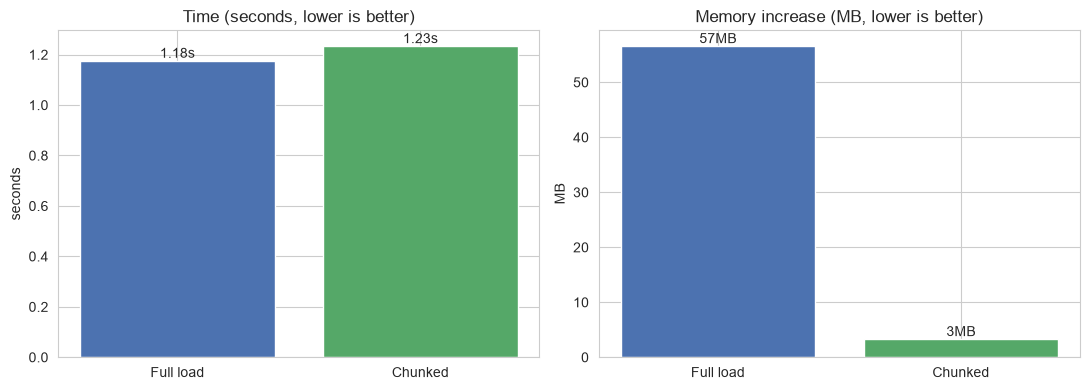

In [16]:
# ─────────────────────────────────────────────
# [도식] 통째로 vs 청크 — 시간/메모리 막대그래프
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

methods = ["Full load", "Chunked"]
times = [elapsed_full, elapsed_chunk]
peaks = [peak_full, peak_chunk]

axes[0].bar(methods, times, color=["#4C72B0", "#55A868"])
axes[0].set_title("Time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

axes[1].bar(methods, peaks, color=["#4C72B0", "#55A868"])
axes[1].set_title("Memory increase (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [17]:
# 스스로 해보자! ✏️
# 1. logs_csv를 chunksize=50_000으로 청크 처리하세요.
# 2. device(mobile/desktop/tablet)별 평균 response_ms를 구하세요.
# 3. 결과를 정렬해서 출력하세요.

# 여기에 코드를 작성하세요

In [18]:
# 모범 답안 — 직접 해본 다음 비교하세요.
sum_dev = {}
cnt_dev = {}
for chunk in pd.read_csv(logs_csv, chunksize=50_000):
    g = chunk.groupby("device")["response_ms"].agg(["sum", "count"])
    for dev, row in g.iterrows():
        sum_dev[dev] = sum_dev.get(dev, 0) + row["sum"]
        cnt_dev[dev] = cnt_dev.get(dev, 0) + row["count"]

result_dev = pd.Series({d: sum_dev[d] / cnt_dev[d] for d in sum_dev}).round(2)
print(result_dev.sort_values())

tablet     159.72
mobile     159.86
desktop    160.11
dtype: float64


## Polars 입문 — 새로운 무대의 등장

# 4. Polars 입문 — 새로운 무대의 등장

pandas는 2008년에 시작된, 데이터 분석의 사실상 표준 도구입니다. 그런데 **수억 행, 수십 GB** 의 데이터를 일상적으로 다루는 시대가 오면서 pandas로는 답답한 일이 점점 늘었습니다. 그래서 등장한 새 도구가 **Polars** — Rust(러스트)라는 빠른 언어로 만든, *현대 하드웨어*에 맞춰 설계된 DataFrame 도구입니다.

> ❓ **이 파트에서 답할 질문:** Polars는 pandas와 무엇이 다를까요? 같은 일을 시키면 코드 모양은 얼마나 비슷할까요?

## 💡 쉽게 말하면 — 같은 무대, 다른 배우

pandas와 Polars는 둘 다 "표 형태의 데이터를 다루는 도구"라는 점에서 같은 무대 위 배우입니다. 그런데 둘이 일하는 방식은 다릅니다.

```text
pandas
  ↓ 데이터를 한 줄씩 처리하는 인터프리터 기반 (느림)
  ↓ 메모리 안에서 사본을 자주 만든다
  ↓ 멀티코어 CPU를 잘 못 쓴다 (대부분 단일 코어)
  → 작은~중간 데이터에 최적. 익숙함이 무기.

Polars
  ↓ Rust 컴파일 언어 기반 (빠름)
  ↓ Arrow 메모리 포맷(컬럼 단위) — 사본을 덜 만듦
  ↓ 멀티코어 병렬 처리가 기본
  → 큰 데이터에 강하다. 코드 패턴은 pandas와 비슷.
```

쉽게 말하면 **pandas는 친숙하고 폭이 넓고, Polars는 새롭고 빠릅니다.** 둘은 라이벌이라기보다 **다른 상황에서 빛나는 도구** 입니다.

## 자세히 알아보기 — Polars의 세 가지 차별점

1. **Rust 기반 컴파일 코드** — 파이썬에서 호출하지만 실제 계산은 컴파일된 빠른 코드에서 일어납니다.
2. **Arrow 컬럼 포맷** — 컬럼 단위로 메모리에 늘어놓아 같은 자료형끼리 모여 있습니다. 캐시 히트율이 높고 사본을 적게 만듭니다.
3. **멀티코어 병렬 처리** — `groupby`·`filter` 같은 연산을 여러 CPU 코어가 나눠서 합니다.

| 비교 항목 | pandas | Polars |
| --- | --- | --- |
| 언어 기반 | 파이썬 + NumPy | Rust |
| 메모리 포맷 | NumPy 배열(컬럼) + 인덱스 | Apache Arrow (컬럼) |
| 인덱스 | 명시적 (`set_index` 등) | 없음 (행은 단순 정렬) |
| 결측 표현 | `NaN`(float) + `NaT` 등 혼합 | `Null` 통일 |
| 병렬 처리 | 제한적 | 기본 제공 |
| API 모양 | `df[df["a"]>0]` | `df.filter(pl.col("a")>0)` |
| Lazy 실행 | 없음 | **있음 (`pl.scan_csv`)** ← Part 5에서 다룸 |

> 💡 **핵심:** Polars는 **인덱스가 없습니다.** pandas에서 인덱스 때문에 헷갈렸던 분이라면 오히려 더 깔끔하게 느낄 수 있어요.

## Polars의 표현식(expression) — `pl.col()`

Polars의 거의 모든 연산은 **표현식(expression)** 으로 작성합니다.

```python
df.filter(pl.col("amount") > 0).group_by("page").agg(pl.col("amount").sum())
```

`pl.col("amount")`는 *"amount라는 컬럼을 가리키는 표현"* 입니다. 이 표현을 다른 함수에 넘기면 Polars가 그 컬럼에 무엇을 할지 *계획*을 세웁니다. 이 계획 기반 실행이 다음 Part에서 다룰 **lazy evaluation** 의 출발점입니다.

## 데이터로 확인해 봅시다 — Polars로 web_logs 읽고 다루기

이제 같은 `web_logs.csv`를 Polars로 읽어 같은 작업을 시켜봅시다. 코드 모양만 봐도 pandas와 얼마나 닮았는지 알 수 있습니다.

> **읽는 법:** Polars의 출력은 pandas보다 좀 더 깔끔합니다. **컬럼별 dtype을 위쪽에 함께 표시**해줘서 자료형을 한눈에 볼 수 있어요. 같은 파일을 읽는 데 보통 Polars가 빠릅니다 — 컴파일 코드와 멀티코어 덕입니다.

> **읽는 법:** Polars의 `group_by()` + `agg()` 패턴은 pandas의 `groupby()` + `agg()`와 모양이 거의 같습니다. 차이는 *표현식(`pl.col(...)`) 으로 컬럼을 가리키는 점*입니다. 보통 Polars가 더 빠릅니다 — 위에서 본 출력에서 확인하셨을 거예요.

## ✏️ 스스로 해보자! — Polars로 디바이스별 합계

Polars로 `device`별로 `bytes_sent`의 **합계** 를 구해보세요.

> 💡 **힌트:** `logs_pl.group_by("device").agg(pl.col("bytes_sent").sum())`

## pandas ↔ Polars 변환

Polars 결과를 pandas로 다시 돌려야 할 때(시각화 라이브러리가 pandas를 요구하거나, 동료가 pandas만 쓸 때)도 한 줄이면 됩니다.

```python
result_pd = result_pl.to_pandas()      # Polars → pandas
result_pl = pl.from_pandas(result_pd)  # pandas → Polars
```

이 *변환 비용은 거의 0* 에 가깝습니다(둘 다 Arrow 기반 메모리를 공유할 수 있기 때문). 그래서 실무에서는 **무거운 처리는 Polars, 시각화는 pandas/seaborn** 같은 식으로 섞어 쓰는 일이 흔합니다.

## 📌 다른 산업에서는?

> 📌 **다른 산업에서는?** Polars는 **데이터 엔지니어링**(ETL 파이프라인), **광고/검색 로그 분석**, **금융 시계열**(분 단위 틱 데이터) 등 *큰 데이터를 빠르게 돌려야 하는 곳*에서 빠르게 자리를 잡고 있습니다. 동시에 익숙함과 생태계를 이유로 **데이터 분석가 일상**(EDA·보고서)은 여전히 pandas가 우세합니다.

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요.

1. Polars가 pandas보다 빠른 이유 두 가지를 들어보세요. (힌트: 언어·코어)
2. Polars에는 *없고* pandas에는 *있는* 개념은 무엇인가요?
3. `pl.col("amount")` 는 무엇을 가리키나요?

> 💡 **다음 Part 예고:** 지금까지 본 Polars는 pandas와 *모양만 다른 빠른 버전* 처럼 보일 수 있어요. 하지만 Polars의 진짜 무기는 따로 있습니다 — **lazy evaluation**. 같은 코드를 실행하기 전에 *계획부터 세워서* 더 똑똑하게 일하는 방식입니다.

In [19]:
# 예제 1: Polars로 CSV 읽기 — pl.read_csv
t0 = time.perf_counter()
logs_pl = pl.read_csv(logs_csv, try_parse_dates=True)
elapsed_pl = time.perf_counter() - t0

# pandas와 같은 작업: 시간 측정용
t0 = time.perf_counter()
logs_pd = pd.read_csv(logs_csv, parse_dates=["ts"])
elapsed_pd = time.perf_counter() - t0

print(f"Polars pl.read_csv : {elapsed_pl:.2f} 초   shape = {logs_pl.shape}")
print(f"pandas pd.read_csv : {elapsed_pd:.2f} 초   shape = {logs_pd.shape}")
print()
print("=== Polars head ===")
print(logs_pl.head())

Polars pl.read_csv : 0.17 초   shape = (500000, 9)
pandas pd.read_csv : 1.11 초   shape = (500000, 9)

=== Polars head ===
shape: (5, 9)
┌────────┬─────────────┬─────────┬────────────┬───┬─────────┬────────────┬────────────┬────────────┐
│ log_id ┆ ts          ┆ user_id ┆ session_id ┆ … ┆ device  ┆ status_cod ┆ response_m ┆ bytes_sent │
│ ---    ┆ ---         ┆ ---     ┆ ---        ┆   ┆ ---     ┆ e          ┆ s          ┆ ---        │
│ i64    ┆ datetime[μs ┆ str     ┆ i64        ┆   ┆ str     ┆ ---        ┆ ---        ┆ i64        │
│        ┆ ]           ┆         ┆            ┆   ┆         ┆ i64        ┆ i64        ┆            │
╞════════╪═════════════╪═════════╪════════════╪═══╪═════════╪════════════╪════════════╪════════════╡
│ 1      ┆ 2025-04-21  ┆ C044419 ┆ 2436       ┆ … ┆ mobile  ┆ 200        ┆ 277        ┆ 84795      │
│        ┆ 15:33:35    ┆         ┆            ┆   ┆         ┆            ┆            ┆            │
│ 2      ┆ 2025-04-14  ┆ C011729 ┆ 10149      ┆ … ┆ mobil

In [20]:
# 예제 2: 같은 작업을 Polars로 — 페이지별 평균 응답 시간
t0 = time.perf_counter()
result_pl = (
    logs_pl
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .sort("page")
)
elapsed_pl = time.perf_counter() - t0

t0 = time.perf_counter()
result_pd = logs_pd.groupby("page")["response_ms"].mean().sort_index().round(2)
elapsed_pd = time.perf_counter() - t0

print(f"Polars group_by + mean : {elapsed_pl*1000:.1f} ms")
print(f"pandas groupby  + mean : {elapsed_pd*1000:.1f} ms")
print()
print("=== Polars 결과 ===")
print(result_pl)

Polars group_by + mean : 14.5 ms
pandas groupby  + mean : 60.5 ms

=== Polars 결과 ===
shape: (7, 2)
┌──────────┬────────────┐
│ page     ┆ avg_ms     │
│ ---      ┆ ---        │
│ str      ┆ f64        │
╞══════════╪════════════╡
│ cart     ┆ 160.27064  │
│ checkout ┆ 159.938837 │
│ detail   ┆ 160.034422 │
│ home     ┆ 159.862077 │
│ list     ┆ 159.966265 │
│ mypage   ┆ 158.343924 │
│ search   ┆ 160.420165 │
└──────────┴────────────┘


In [21]:
# 스스로 해보자! ✏️
# 1. logs_pl을 group_by('device')로 묶으세요.
# 2. bytes_sent의 합계를 구하세요.
# 3. 합계 컬럼명을 'total_bytes'로 바꾸세요.

# 여기에 코드를 작성하세요

In [22]:
# 모범 답안 — 직접 해본 다음 비교하세요.
ans = (
    logs_pl
    .group_by("device")
    .agg(pl.col("bytes_sent").sum().alias("total_bytes"))
    .sort("total_bytes", descending=True)
)
print(ans)

shape: (3, 2)
┌─────────┬─────────────┐
│ device  ┆ total_bytes │
│ ---     ┆ ---         │
│ str     ┆ i64         │
╞═════════╪═════════════╡
│ mobile  ┆ 35107613460 │
│ desktop ┆ 12616794831 │
│ tablet  ┆ 2467104056  │
└─────────┴─────────────┘


## Lazy evaluation — 계획부터 세우는 실행

# 5. Lazy evaluation — 계획부터 세우는 실행

지금까지 본 모든 코드는 한 줄을 쓰자마자 곧장 실행되는 방식이었습니다. `pd.read_csv(...)` 한 줄에 파일이 통째로 읽히고, `.filter(...)` 한 줄에 곧장 행이 걸러집니다. 이런 방식을 **즉시 실행(eager evaluation)** 이라고 부릅니다. pandas는 100% eager 방식입니다.

Polars의 진짜 강점은 **lazy evaluation** 모드를 함께 제공한다는 점입니다. 코드를 쓴 순간에는 아무것도 실행하지 않고, *계획만 세워둡니다*. 마지막에 `.collect()`라고 신호를 줬을 때 비로소 *계획 전체를 한꺼번에 최적화해서* 실행합니다.

> ❓ **이 파트에서 답할 질문:** 같은 작업인데 왜 lazy 모드가 더 빠를까요? 그 비밀은 어디 있을까요?

## 💡 쉽게 말하면 — 마트 한 번에 다녀오기

마트 갈 일이 다섯 가지 있다고 상상해보세요.

```text
[즉시 실행 모드 — pandas 스타일]
  "우유 사러 갈게요" → 다녀옴 → "이번엔 빵" → 다녀옴 → "이번엔 과일" → 다녀옴 ...
  → 다섯 번 왕복. 시간과 기름 낭비.

[Lazy 모드 — Polars 스타일]
  "우유, 빵, 과일, 세제, 휴지 사러 갈게요" → 한 번에 다녀옴
  → 가는 길에 효율적으로 들름. 한 번만 왕복.
```

데이터 처리도 똑같습니다. 필터·정렬·집계를 따로따로 실행하면 매 단계마다 *전체 데이터를 한 번씩 훑습니다*. 반면 lazy 모드는 모든 단계를 받아본 다음에 **"어차피 이런 행만 살아남을 텐데, 처음부터 그 행만 읽자"**, **"이 컬럼은 안 쓰니까 처음부터 안 읽자"** 같은 최적화를 적용합니다.

## 자세히 알아보기 — `pl.scan_csv` 와 `.collect()`

Polars의 lazy 모드는 두 가지로 시작합니다.

- `pl.scan_csv("file.csv")` — CSV를 *읽지 않고* 읽을 계획만 세웁니다. 결과는 `LazyFrame`.
- `lazy_df.collect()` — 그동안 쌓인 계획을 한꺼번에 실행.

코드 모양은 거의 같지만 동작이 다릅니다.

```python
# eager (즉시): 한 줄 한 줄 곧장 실행
df = pl.read_csv("big.csv")
df = df.filter(pl.col("status") == 200)
df = df.group_by("page").agg(pl.col("ms").mean())
# → 파일 전체를 메모리에 올림 → 필터 → 다시 집계 (3단계 모두 즉시)

# lazy (지연): 계획만 세우고 마지막에 한 번 실행
df = (
    pl.scan_csv("big.csv")
    .filter(pl.col("status") == 200)
    .group_by("page").agg(pl.col("ms").mean())
).collect()
# → 'status==200이고 page/ms만 쓴다'를 알아냄
# → 처음부터 그 컬럼·그 행만 읽음 → 한 번에 집계
```

### Polars의 내부 최적화 3가지

| 최적화 | 무엇을 하나 | 효과 |
| --- | --- | --- |
| **Predicate pushdown** | 필터를 *읽는 단계*로 끌어내려 함 | 통과할 행만 메모리에 올림 |
| **Projection pushdown** | 결과에 안 쓰는 컬럼은 처음부터 안 읽음 | 메모리·시간 절약 |
| **Common subexpression** | 같은 표현을 두 번 계산하지 않음 | 시간 절약 |

이 세 가지를 *프로그래머가 신경 쓰지 않아도* Polars가 자동으로 합니다. 그게 lazy의 매력입니다.

## 데이터로 확인해 봅시다 — 같은 작업을 eager vs lazy 로

같은 분석을 eager 와 lazy 두 방식으로 짜고 시간을 측정해봅시다.

> **읽는 법:** 두 결과는 동일합니다. 그런데 일반적으로 lazy 쪽이 더 빠릅니다 — `status_code == 200` 필터를 *읽는 단계*로 밀어 넣고, `response_ms`·`page`·`status_code`만 읽기 때문이에요. 우리가 신경 안 써도 Polars가 알아서 합니다.

## 계획을 들여다보기 — `.explain()`

lazy 모드의 또 하나의 장점은 **실행 전에 계획을 볼 수 있다는 것** 입니다. 어떤 최적화가 적용됐는지를 인간이 읽을 수 있는 형태로 보여줍니다.

> **읽는_법:** 출력의 끝쪽에 `PROJECT … COLUMNS` 또는 `SELECTION` 같은 단어가 보일 거예요. 이게 **Polars가 자동으로 적용한 최적화** 입니다. "이 컬럼만 읽고, 이 조건만 통과시킨다"는 계획이 미리 세워졌다는 뜻입니다.

## Lazy의 진짜 위력 — 디스크보다 큰 데이터?

lazy 모드는 진짜 큰 데이터에서 위력이 빛납니다. 예를 들어 `scan_csv` 다음에 강한 필터(`status_code == 500`처럼 1%만 통과)를 두면, *그 1%만 메모리에 올리는* 효과가 납니다. eager 방식으로는 일단 100%를 다 읽어야 하지요.

> 💡 **핵심:** **"먼저 큰 깔때기, 나중에 좁은 작업"** 의 패턴이 lazy의 진짜 친구입니다. 데이터를 일찍 좁힐수록 lazy가 더 많이 절약해줍니다.

## ✏️ 스스로 해보자! — lazy 모드로 4XX/5XX 에러 분석

`logs_csv`에서 **`status_code >= 400`** 인 행만 골라 페이지별 에러 수를 세어보세요. **lazy 모드(`pl.scan_csv` + `.collect()`)** 로 작성합니다.

> 💡 **힌트:** 필터를 먼저 두면 Predicate pushdown 효과가 큽니다.

## 📌 다른 산업에서는?

> 📌 **다른 산업에서는?** Lazy 평가는 **데이터 엔지니어링** 의 표준입니다. Spark·SQL·dbt·Dask — 큰 데이터를 다루는 도구는 거의 다 lazy 패러다임을 가집니다. **금융** 의 대용량 시계열 분석, **광고** 의 어트리뷰션 파이프라인, **제조** 의 라인별 일일 집계 모두 같은 발상을 씁니다. *Polars의 lazy 모드는 이 패러다임을 분석가의 노트북에 가져온 것* 입니다.

## 💡 더 알고 싶다면 — SQL과 lazy의 닮은 점

> 💡 **더 알고 싶다면:** SQL 쿼리(`SELECT ... FROM ... WHERE ... GROUP BY ...`)도 본질적으로 **lazy** 입니다. 데이터베이스가 쿼리를 받으면 그 즉시 실행하지 않고, 먼저 *실행 계획(query plan)* 을 짠 다음 최적화해서 실행합니다. Polars의 lazy 모드는 *분석가에게 SQL 같은 엔진을 내준 것* 으로 봐도 좋습니다.

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요.

1. `pl.read_csv`와 `pl.scan_csv`의 차이는 무엇인가요?
2. lazy 모드에서 실제 실행을 시작시키는 메서드는 무엇인가요?
3. Predicate pushdown은 무엇을 하나요?

> 💡 **다음 Part 예고:** dtype 최적화·청크·Polars·lazy까지 네 가지 카드를 가졌습니다. 이제 직접 측정해서 *누가 언제 빠른지* 숫자로 비교해봅시다. **측정 없는 도구 선택은 신앙고백** 이니까요.

In [23]:
# 예제 1: eager 방식 — 한 줄씩 즉시 실행
t0 = time.perf_counter()
result_eager = (
    pl.read_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
)
elapsed_eager = time.perf_counter() - t0

print(f"Eager  : {elapsed_eager*1000:6.1f} ms")
print(result_eager)

Eager  :  200.7 ms
shape: (7, 3)
┌──────────┬────────────┬────────┐
│ page     ┆ avg_ms     ┆ n_rows │
│ ---      ┆ ---        ┆ ---    │
│ str      ┆ f64        ┆ u32    │
╞══════════╪════════════╪════════╡
│ mypage   ┆ 158.164001 ┆ 14378  │
│ list     ┆ 159.704364 ┆ 71260  │
│ home     ┆ 159.858675 ┆ 85689  │
│ cart     ┆ 160.040313 ┆ 28527  │
│ detail   ┆ 160.16073  ┆ 57500  │
│ checkout ┆ 161.431966 ┆ 14309  │
│ search   ┆ 161.780443 ┆ 14133  │
└──────────┴────────────┴────────┘


In [24]:
# 예제 2: lazy 방식 — scan_csv로 계획만, 마지막에 collect()
t0 = time.perf_counter()
result_lazy = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
    .collect()
)
elapsed_lazy = time.perf_counter() - t0

print(f"Lazy   : {elapsed_lazy*1000:6.1f} ms")
print(result_lazy)

Lazy   :   68.7 ms
shape: (7, 3)
┌──────────┬────────────┬────────┐
│ page     ┆ avg_ms     ┆ n_rows │
│ ---      ┆ ---        ┆ ---    │
│ str      ┆ f64        ┆ u32    │
╞══════════╪════════════╪════════╡
│ mypage   ┆ 158.164001 ┆ 14378  │
│ list     ┆ 159.704364 ┆ 71260  │
│ home     ┆ 159.858675 ┆ 85689  │
│ cart     ┆ 160.040313 ┆ 28527  │
│ detail   ┆ 160.16073  ┆ 57500  │
│ checkout ┆ 161.431966 ┆ 14309  │
│ search   ┆ 161.780443 ┆ 14133  │
└──────────┴────────────┴────────┘


In [25]:
# 예제 3: Polars가 어떤 계획을 세웠는지 확인 — .explain()
plan = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .explain()
)
print(plan)

AGGREGATE[maintain_order: false]
  [col("response_ms").mean().alias("avg_ms")] BY [col("page")]
  FROM
  simple π 2/2 ["page", "response_ms"]
    Csv SCAN [moodumarket_big/web_logs.csv]
    PROJECT 3/9 COLUMNS
    SELECTION: [(col("status_code")) == (200)]
    ESTIMATED ROWS: 537363


In [26]:
# 스스로 해보자! ✏️
# 1. pl.scan_csv로 logs_csv를 lazy 모드로 엽니다.
# 2. status_code >= 400 인 행만 필터링하세요.
# 3. page별로 row 개수를 세고, 많은 순으로 정렬하세요.
# 4. .collect()로 실행하세요.

# 여기에 코드를 작성하세요

In [27]:
# 모범 답안 — 직접 해본 다음 비교하세요.
error_summary = (
    pl.scan_csv(logs_csv)
    .filter(pl.col("status_code") >= 400)
    .group_by("page")
    .agg(pl.len().alias("n_errors"))
    .sort("n_errors", descending=True)
    .collect()
)
print(error_summary)

shape: (7, 2)
┌──────────┬──────────┐
│ page     ┆ n_errors │
│ ---      ┆ ---      │
│ str      ┆ u32      │
╞══════════╪══════════╡
│ home     ┆ 42898    │
│ list     ┆ 35593    │
│ detail   ┆ 28298    │
│ cart     ┆ 14360    │
│ search   ┆ 7256     │
│ mypage   ┆ 7244     │
│ checkout ┆ 7108     │
└──────────┴──────────┘


## pandas vs Polars — 직접 측정해보기

# 6. pandas vs Polars — 직접 측정해보기

이제 도구를 다 만났으니, *같은 일을 시키면 누가 더 빠른지* 직접 측정해볼 차례입니다. 인터넷에 떠도는 벤치마크 그래프는 멋있지만 **여러분의 환경, 여러분의 데이터** 에서 다시 재봐야 의미가 있습니다. 머신·데이터 크기·쿼리 종류에 따라 결과가 달라지기 때문이에요.

> ❓ **이 파트에서 답할 질문:** 우리 환경, 우리 web_logs에서 pandas와 Polars(eager / lazy)는 어떤 작업에서 얼마나 차이가 나는가?

## 💡 쉽게 말하면 — 한 사람이 두 도구를 같은 책상에서 쓴다

```text
같은 책상(머신) · 같은 책(데이터) · 같은 질문(쿼리)
                ↓                    ↓                   ↓
        [pandas로 풀기]   [Polars eager로 풀기]   [Polars lazy로 풀기]
                ↓                    ↓                   ↓
              걸린 시간 · 사용 메모리 · 결과 동등성 비교
```

핵심은 "**누가 더 빠르다**"가 아니라, **여러분의 환경에서 직접 측정한 숫자**입니다. 그래야 *내 일의 어떤 작업에서 어느 도구가 유리한지* 라는 경험치가 쌓이고, 다음 도구 선택의 근거가 됩니다.

## 벤치마크 작업 4종

공정하게 비교하려면 *같은 작업* 을 *같은 데이터* 에 대해 실행해야 합니다. 다음 4가지 작업을 정해놓고 셋(`pandas`, `polars eager`, `polars lazy`)을 모두 돌립니다.

| # | 작업 | 무엇을 보나 |
| --- | --- | --- |
| Q1 | 페이지별 평균 응답 시간 | 단순 그룹 집계 |
| Q2 | 디바이스별 총 트래픽 합계 | 합산 위주 |
| Q3 | `status_code >= 400` 인 페이지별 에러 수 | 필터 + 집계 (pushdown 유리) |
| Q4 | 페이지별 응답 시간의 *중앙값* | 분포 계산 (정렬 필요) |

## 데이터로 확인해 봅시다 — 벤치마크 코드 작성

분석가의 일은 *측정 가능한 형태* 로 만드는 것입니다. 같은 함수에 같은 입력을 주고, *순수 처리 시간만* 재도록 코드를 정리합시다.

## 한 장에 모아 보기

수치를 다 모았으니 시각화로 한눈에 봅시다.

> **읽는 법:** 대체로 Polars가 pandas보다 빠르고, 특히 **Q3(필터+집계)** 와 **Q4(중앙값)** 처럼 무거운 작업에서 격차가 커집니다. lazy 모드는 eager보다 조금 더 빠를 때가 많은데, 데이터를 일찍 좁히는 쿼리(Q3)에서 특히 효과적입니다.

## 결과 해석 가이드 — "왜 이 차이가 나는가"

벤치마크는 *왜 그렇게 나오는지* 를 함께 설명할 수 있어야 의미 있는 결과입니다.

| 관찰 | 가능한 원인 |
| --- | --- |
| Polars가 Q1·Q2에서 빠름 | 멀티코어 병렬 처리 + 컬럼 포맷의 캐시 효율 |
| Polars가 Q3에서 *훨씬* 빠름 | Predicate pushdown — 통과할 행만 읽음 |
| Polars가 Q4에서 빠름 | 중앙값은 정렬이 필요한데 Rust 구현이 강함 |
| lazy가 eager와 비슷한 케이스 | 작업이 워낙 단순해 최적화 여지가 적음 |
| pandas가 작은 데이터에서 비슷 | 오버헤드 차이가 데이터가 작을 때 안 두드러짐 |

> ⚠ **주의:** 벤치마크 결과는 **여러분의 머신/캐시 상태/다른 프로세스 영향** 에 좌우됩니다. 같은 코드를 두 번 돌렸을 때 결과가 다르면 그게 정상입니다. *반복 평균* 을 보는 이유가 여기 있습니다.

## ✏️ 스스로 해보자! — 본인 쿼리 추가하기

여러분이 자주 하는 쿼리 1개를 골라, pandas / polars eager / polars lazy 세 가지로 시간을 측정해보세요. 위의 `benchmark()` 함수를 그대로 쓰면 됩니다.

> 💡 **힌트:** 단순 그룹 평균보다는 *필터 + 집계 + 정렬* 처럼 단계가 여럿 있는 쿼리가 차이를 더 잘 보여줍니다.

## 📌 다른 산업에서는?

> 📌 **다른 산업에서는?** 벤치마크 문화는 **데이터 엔지니어링·SRE** 의 일상입니다. **광고/검색** 의 쿼리 응답 시간 벤치, **금융** 의 리스크 계산 SLA, **제조** 의 라인 모니터링 처리량 — 측정 없이는 개선도 없습니다. 분석가가 도구 선택을 *측정 결과로 정당화* 하는 습관은 어디에서도 통합니다.

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요.

1. Polars가 pandas보다 빠른 쿼리 유형의 공통점은 무엇인가요?
2. lazy 모드가 eager보다 *더* 빠른 시점은 어떤 패턴일 때인가요?
3. 같은 벤치마크를 다시 돌리면 시간이 약간씩 다른 이유는 무엇인가요?

> 💡 **다음 Part 예고:** 측정 결과를 봤으니 이제 *진짜 질문* 에 답할 차례입니다. **"언제 무엇을 쓸 것인가?"** 도구 선택의 의사결정 프레임을 만들어봅시다.

In [28]:
# 벤치마크 유틸 — 같은 작업을 N회 돌려 평균 시간을 측정
def benchmark(label, func, n=3):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        times.append(time.perf_counter() - t0)
    avg_ms = sum(times) / n * 1000
    print(f"{label:24s}: {avg_ms:7.1f} ms   (n={n}, min={min(times)*1000:.1f}ms)")
    return avg_ms

# 측정 대상 함수들 — Q1: 페이지별 평균 응답 시간
def q1_pandas():
    return (
        pd.read_csv(logs_csv)
        .groupby("page")["response_ms"].mean()
    )

def q1_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
    )

def q1_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
        .collect()
    )

print("=== Q1: 페이지별 평균 응답 시간 ===")
q1_pd = benchmark("pandas",        q1_pandas)
q1_pe = benchmark("polars (eager)", q1_polars_eager)
q1_pl = benchmark("polars (lazy)",  q1_polars_lazy)

=== Q1: 페이지별 평균 응답 시간 ===


pandas                  :  1004.7 ms   (n=3, min=993.5ms)
polars (eager)          :    39.0 ms   (n=3, min=32.3ms)
polars (lazy)           :    45.5 ms   (n=3, min=40.2ms)


In [39]:
pd.read_csv(logs_csv).head(5)


# Q2: 디바이스별 bytes_sent 합계
def q2_pandas():
    return pd.read_csv(logs_csv).groupby("device")["bytes_sent"].sum()

def q2_polars_eager():
    return pl.read_csv(logs_csv).group_by("device").agg(pl.col("bytes_sent").sum())

def q2_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("device")
        .agg(pl.col("bytes_sent").sum())
        .collect()
    )

print("=== Q2: 디바이스별 bytes_sent 합계 ===")
q2_pd = benchmark("pandas",        q2_pandas)
q2_pe = benchmark("polars (eager)", q2_polars_eager)
q2_pl = benchmark("polars (lazy)",  q2_polars_lazy)

=== Q2: 디바이스별 bytes_sent 합계 ===
pandas                  :   981.6 ms   (n=3, min=959.7ms)
polars (eager)          :    39.9 ms   (n=3, min=36.4ms)
polars (lazy)           :    47.1 ms   (n=3, min=42.7ms)


In [30]:
# Q3: status_code >= 400 페이지별 에러 수 (필터 + 집계 → pushdown 유리)
def q3_pandas():
    df = pd.read_csv(logs_csv)
    return df[df["status_code"] >= 400].groupby("page").size()

def q3_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
    )

def q3_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
        .collect()
    )

print("=== Q3: status_code>=400 페이지별 에러 수 ===")
q3_pd = benchmark("pandas",        q3_pandas)
q3_pe = benchmark("polars (eager)", q3_polars_eager)
q3_pl = benchmark("polars (lazy)",  q3_polars_lazy)

=== Q3: status_code>=400 페이지별 에러 수 ===
pandas                  :   926.6 ms   (n=3, min=911.8ms)
polars (eager)          :    44.6 ms   (n=3, min=40.4ms)
polars (lazy)           :    47.9 ms   (n=3, min=41.9ms)


In [31]:
# Q4: 페이지별 응답 시간의 중앙값 (정렬 필요, pandas 약점)
def q4_pandas():
    return pd.read_csv(logs_csv).groupby("page")["response_ms"].median()

def q4_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
    )

def q4_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
        .collect()
    )

print("=== Q4: 페이지별 응답 시간 중앙값 ===")
q4_pd = benchmark("pandas",        q4_pandas)
q4_pe = benchmark("polars (eager)", q4_polars_eager)
q4_pl = benchmark("polars (lazy)",  q4_polars_lazy)

=== Q4: 페이지별 응답 시간 중앙값 ===
pandas                  :   962.5 ms   (n=3, min=922.7ms)
polars (eager)          :    48.5 ms   (n=3, min=46.8ms)
polars (lazy)           :    54.4 ms   (n=3, min=50.1ms)


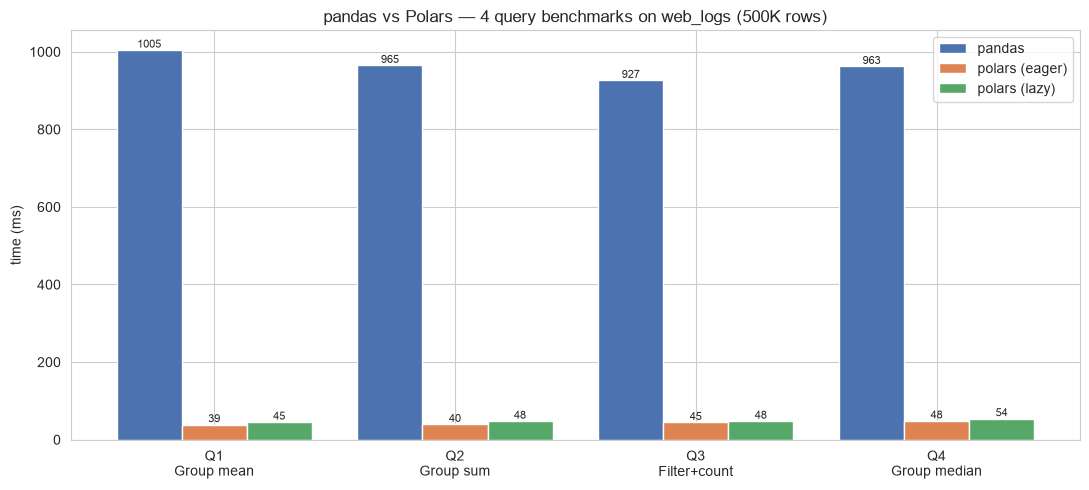

In [32]:
# ─────────────────────────────────────────────
# [도식] 4개 쿼리 × 3개 도구 비교 막대그래프
# ─────────────────────────────────────────────
queries = ["Q1\nGroup mean", "Q2\nGroup sum", "Q3\nFilter+count", "Q4\nGroup median"]
pd_times = [q1_pd, q2_pd, q3_pd, q4_pd]
pe_times = [q1_pe, q2_pe, q3_pe, q4_pe]
pl_times = [q1_pl, q2_pl, q3_pl, q4_pl]

x = np.arange(len(queries))
width = 0.27

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, pd_times, width, label="pandas", color="#4C72B0")
ax.bar(x,         pe_times, width, label="polars (eager)", color="#DD8452")
ax.bar(x + width, pl_times, width, label="polars (lazy)", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(queries)
ax.set_ylabel("time (ms)")
ax.set_title("pandas vs Polars — 4 query benchmarks on web_logs (500K rows)")
ax.legend()

# 각 막대 위에 숫자 표기
for arr, off in [(pd_times, -width), (pe_times, 0), (pl_times, width)]:
    for i, v in enumerate(arr):
        ax.text(i + off, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [33]:
# 스스로 해보자! ✏️
# 1. 본인이 보고 싶은 쿼리를 정합니다. (예: 채널이 'mobile'이고 status==200인 행의 page별 평균 bytes_sent)
# 2. 같은 쿼리를 pandas / polars eager / polars lazy 로 작성하세요.
# 3. benchmark()로 세 가지 시간을 출력하세요.

# 여기에 코드를 작성하세요

## 도구 선택 의사결정 — 언제 무엇을 쓸까

# 7. 도구 선택 의사결정 — 언제 무엇을 쓸까

지금까지 우리는 네 가지 무기를 익혔습니다.

1. **pandas (그냥 쓰기)** — 익숙하고 자료가 많음
2. **dtype 최적화** — 같은 데이터를 더 작게
3. **청크 처리** — 메모리에 안 들어갈 때 나눠 읽기
4. **Polars (eager / lazy)** — 빠른 대안

문제는 *어느 상황에서 무엇을 꺼낼지* 입니다. 모두 쓰면 좋지만 모두 학습 비용이 듭니다. 분석가에게는 *상황별 첫 번째 선택* 이 필요합니다.

> ❓ **이 파트에서 답할 질문:** 데이터 크기·요구사항·팀 환경에 따라 어떤 도구를 첫 번째로 꺼낼까요?

## 💡 쉽게 말하면 — 망치 하나가 아니라 '연장 가방'

어떤 도구가 "더 좋다"가 아니라 **어느 상황에 어느 도구**입니다. 분석가의 가방에는 pandas·dtype 최적화·청크·Polars가 모두 들어 있고, 데이터 크기·요구사항·팀 환경 세 축을 보고 *그때그때 꺼내* 씁니다.

```text
   망치(pandas)         드라이버(청크)           스패너(Polars)
   ──────────         ──────────              ──────────
   작은 못 박기         메모리 부족 시            대용량 / 자동화
   익숙·빠른 학습       나눠 처리                 lazy로 메모리 절약
```

망치 하나로 모든 못을 박지 않는 것처럼, 도구 하나로 모든 데이터 크기를 다루지 않습니다.

## 의사결정 프레임 — 데이터 크기 × 요구사항 × 팀 환경

```text
                      ┌── < 10만 행  → pandas (그대로) ── 굳이 새 도구 부담 X
   [1] 데이터 크기? ──┼── 10만~100만 → pandas + dtype 최적화
                      ├── 100만~1억  → Polars (eager 또는 lazy)
                      └── > 1억     → Polars lazy 또는 Spark/DB

                      ┌── 빠르게 결과만 → pandas (익숙함)
   [2] 요구사항? ─────┼── 메모리가 부족 → 청크 처리 / Polars lazy
                      └── 매일 자동 실행 → Polars lazy (재현성·속도)

                      ┌── 동료 다 pandas → pandas 유지 (협업 비용)
   [3] 팀 환경? ──────┼── 사내 Polars 도입 진행 중 → Polars 시도
                      └── 혼자 작업 → 어느 쪽이든 OK
```

이 세 축은 *동시에* 고려해야 합니다. 가장 큰 함정은 "**무조건 Polars 가 빠르니까 Polars 쓰자**" — 작은 데이터에서는 학습 비용만 늘 뿐 이득이 거의 없습니다.

## 자세히 알아보기 — 데이터 크기별 추천 정리

| 데이터 크기 | 1차 선택 | 2차 선택 (메모리 부족 시) | 비고 |
| --- | --- | --- | --- |
| < 10만 행 | **pandas** | — | 도구 바꿀 이유 없음 |
| 10만 ~ 100만 행 | **pandas + dtype** | 청크 처리 | dtype 다이어트만으로 충분한 경우 多 |
| 100만 ~ 1천만 행 | **Polars (eager)** | Polars lazy | 속도 차이가 체감 |
| 1천만 ~ 1억 행 | **Polars (lazy)** | 청크 처리 + 디스크 캐시 | lazy의 pushdown 효과 큼 |
| > 1억 행 | **Polars lazy + Parquet** | 외부 도구 (Spark, DuckDB, DB) | 노트북 한 대로는 한계 |

## 데이터로 확인해 봅시다 — 의사결정 흐름도 그리기

위 표를 *코드*로 표현해두면, 새 데이터가 들어왔을 때 자동으로 도구를 추천할 수 있습니다.

> **읽는 법:** 같은 파일이라도 *팀이 Polars를 쓰는가* 같은 환경 변수에 따라 추천이 달라집니다. 의사결정은 *데이터만의 문제가 아니라 사람의 문제* 라는 사실을 잊지 마세요.

## 안티패턴 — 이런 선택은 피하세요

| 안티패턴 | 무엇이 문제인가 | 대신 |
| --- | --- | --- |
| 1천 행 데이터에 Polars 도입 | 학습·코드 가독성 비용만 발생 | pandas로 충분 |
| dtype 최적화 없이 곧장 청크 | 어쩌면 다이어트만으로 풀렸을 일 | 1차로 dtype 시도 |
| `pl.read_csv` (eager) 만 사용 | lazy 의 pushdown 혜택을 못 받음 | `scan_csv` + `.collect()` 시도 |
| 측정 없는 도구 결정 | 신앙고백 | benchmark 한 번 돌리기 |

## ✏️ 스스로 해보자! — 의사결정 시나리오

다음 시나리오를 읽고, 어떤 도구를 1차로 추천하시겠어요? 그리고 그 이유를 한 줄로 적어보세요.

1. **시나리오 A** — 5천 행짜리 매출 요약 보고서. 매주 손으로 돌림.
2. **시나리오 B** — 매일 자동 실행되는 광고 로그(2,000만 행) ETL 파이프라인.
3. **시나리오 C** — 50만 행짜리 고객 분석. 동료가 모두 pandas만 씀.

> 💡 **힌트:** 데이터 크기 외에 *자동 실행* 인지, *팀 환경* 이 어떤지를 함께 고려하세요.

## 📌 다른 산업에서는?

> 📌 **다른 산업에서는?** "어느 도구를 쓸지" 결정은 **모든 직무** 의 공통 과제입니다. **마케팅** 의 분석 도구(Excel vs SQL vs 파이썬), **금융** 의 모델링 환경(R vs 파이썬), **데이터 엔지니어링** 의 처리 엔진(Spark vs Polars vs DuckDB) — 결정 프레임은 같습니다: *크기 × 요구사항 × 팀 환경*.

### ✅ 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요.

1. 10만 행 데이터에 1차로 추천할 도구는 무엇인가요?
2. "팀 환경"이 도구 선택에 영향을 주는 이유는 무엇인가요?
3. 안티패턴 4가지 중 가장 자주 본인이 빠질 것 같은 함정은 무엇인가요?

> 💡 **다음 Part 예고:** 이제 모든 카드를 손에 들었습니다. 종합 실습에서 **실제 시나리오** 에 적용하고, *측정 결과로 선택을 정당화* 하는 보고서까지 작성해봅시다.

# 🎯 종합 실습 — 대용량 이커머스 로그 처리 마무리

지금까지 배운 모든 무기를 한 자리에 모읍니다. 시나리오는 단순합니다.

> 모두마켓의 **월간 웹 로그(500K 행)** 를 분석해 (1) 페이지별 응답 시간 분포, (2) 디바이스별 트래픽 점유율, (3) 에러(`status_code >= 400`) 발생 패턴을 정리하고, **어떤 도구 조합을 골랐는지 측정 결과를 근거로 한 단락으로 정당화** 하세요.

산출물은 노트북 안 마크다운 셀로 작성된 **"도구 선택 보고서"** + 분석 결과 표·그림입니다.

## 시나리오 1 — pandas + dtype 최적화로 풀기

먼저 가장 익숙한 pandas로 풉니다. dtype 최적화를 적용해 메모리를 최소화하세요.

## 시나리오 2 — 청크 처리로 풀기

이번엔 청크로 풀어봅니다. 같은 결과가 나와야 합니다 — 합치는 로직을 *손으로* 짜는 경험이 핵심입니다.

## 시나리오 3 — Polars lazy로 풀기

마지막은 Polars의 lazy 모드입니다. **읽기 → 필터 → 집계 → collect** 의 단일 파이프라인으로 표현해보세요.

## 결과 비교 — 세 가지 방식 한 자리에

## 📊 "도구 선택 보고서" 작성

지금까지의 측정 결과를 근거로, *모두마켓 월간 웹 로그 분석에 어떤 도구를 추천하는지* 보고서를 한 단락으로 정리하세요. 이것이 오늘의 최종 산출물이며, 과제로 제출합니다.

```markdown
# 모두마켓 월간 로그 — 도구 선택 보고서

## 1. 데이터 개요
- 파일: web_logs.csv
- 크기: ___ MB, ___ 행
- 주요 컬럼: ts / user_id / page / device / status_code / response_ms / bytes_sent

## 2. 측정 결과
| 방식 | 소요 시간 | 메모리 피크 |
|---|---|---|
| pandas + dtype | ___초 | ___MB |
| pandas chunked | ___초 | ___MB |
| Polars lazy    | ___초 | ___MB |

## 3. 분석 결과 요약
- 페이지별 평균 응답 시간 최고: ___ (___ms)
- 디바이스 점유율: mobile ___%, desktop ___%, tablet ___%
- 에러 1위 페이지: ___ (___건)

## 4. 도구 선택 정당화 (한 단락)
이 분석에는 **___ (도구 이름)** 을 선택했습니다. 이유는
(1) 측정 결과 ___ 가 가장 ___, (2) 팀 환경상 ___, (3) ___.

## 5. 다음 단계 제안
- 데이터 크기가 ___ 까지 늘어나면 ___ 로 전환을 고려.
- 시각화·검증은 D+008에서 ___ 을 활용해 진행.
```

> 💡 빈칸(___) 은 위 셀들의 실행 결과로 직접 채워 넣으세요. **숫자 + 한 줄 근거** 가 함께 들어가야 좋은 보고서입니다.

## 시나리오 4 — 도전 과제(선택)

여러분 환경에서 `chunksize`를 `10_000` ↔ `100_000` 로 바꿔가며 시나리오 2를 다시 돌려보세요. 청크 크기가 *시간과 메모리에 어떻게 영향을 주는지* 직접 측정해보면, 의사결정의 한 축이 더 단단해집니다.

# ✅ 오늘의 퀴즈

배운 내용을 잠깐 확인해볼게요. 틀려도 괜찮습니다. "이런 걸 배웠지" 하고 떠올리는 용도예요.

### 개념 퀴즈

1. pandas가 메모리에 데이터를 다 못 올릴 때 가장 먼저 시도해볼 두 가지 전략은 무엇인가요?
2. `int8`로 표현 가능한 값의 범위는 어떻게 되나요? `(a) -128~127  (b) 0~255  (c) -32768~32767`
3. 청크 처리에서 *평균* 을 합칠 때 "평균의 평균"이 틀린 이유는 무엇인가요?
4. Polars의 lazy 모드 시작 함수는 `pl.read_csv` 일까요, `pl.scan_csv` 일까요?
5. 데이터가 1억 행이고 매일 자동 실행 파이프라인이라면 첫 번째로 추천할 도구는 무엇인가요?

### 코드 퀴즈

`logs_csv`에서 **`device == 'mobile'`** 이고 **`status_code == 200`** 인 행만 골라, **`page`별 `response_ms`의 95-percentile** 을 구하세요. **Polars lazy 모드** 로 작성합니다.

> **읽는_법:** `(조건1) & (조건2)` 처럼 두 조건을 묶을 때는 *각 조건을 괄호로 감싸* 야 합니다. `quantile(0.95)`는 95번째 백분위수 — "응답 시간이 이보다 빠른 요청이 95%" 라는 뜻이에요. 페이지별로 *상위 5% 느린 요청* 의 응답 시간을 볼 수 있습니다.

# 🎓 정리 & 다음 시간 예고

## 오늘 배운 것이 어떻게 이어졌나

```text
[Part 1] pandas 메모리 한계        — 책상의 크기를 알자
   ↓  (한계를 알았으니 줄일 방법을 찾자)
[Part 2] dtype 최적화              — 같은 값을 더 작은 그릇에
   ↓  (그래도 안 들어가면)
[Part 3] 청크 처리                  — 나눠 읽고 합치기
   ↓  (좀 더 근본적인 도구가 있을까)
[Part 4] Polars 입문                — Rust 기반의 새 무대
   ↓  (그 무대의 진짜 무기)
[Part 5] Lazy evaluation            — 계획부터 세우는 실행
   ↓  (말로만 하지 말고)
[Part 6] pandas vs Polars 측정      — 직접 비교
   ↓  (그래서 언제 무엇을?)
[Part 7] 도구 선택 의사결정         — 크기·요구·팀
   ↓
[종합 실습] 측정 결과로 선택을 정당화
```

## 한 장 정리표

| 주제 | 핵심 한 줄 | 대표 코드 |
| --- | --- | --- |
| pandas 한계 | 전부 메모리, 사본 잦음 | `df.memory_usage(deep=True)` |
| dtype | 같은 값을 더 작게 | `df["col"].astype("int8" / "category")` |
| 청크 | 나눠서 읽고 합치기 | `pd.read_csv(..., chunksize=50_000)` |
| Polars | Rust·Arrow·멀티코어 | `pl.read_csv(...)` |
| Lazy | 계획 후 한 번에 | `pl.scan_csv(...).collect()` |
| 측정 | 숫자로 선택 정당화 | `time.perf_counter()`, `psutil` |
| 의사결정 | 크기 × 요구 × 팀 | `recommend_tool(file)` |

## 진단 결과 → 다음에 할 일 (학습 지도)

오늘 측정한 결과들이 다음 단계의 *행동* 으로 연결됩니다.

| 오늘 발견한 신호 | 자연스러운 다음 분석 |
| --- | --- |
| 페이지별 응답 시간 분포 | 분포 시각화 — **다음 시간** |
| 디바이스 점유율의 큰 격차 | 비교 차트(Seaborn) — **다음 시간** |
| 에러 페이지의 시계열 패턴 | 시계열 시각화 + 인터랙티브(Plotly) — **다음 시간** |
| 측정 결과를 동료와 공유 | 시각화 보고서 양식 — **다음 시간** |

## 🎓 다음 시간 예고

> **"처리한 데이터를 이제 *눈으로* 검증하고 탐색한다."**
>
> 오늘 우리는 큰 데이터를 *처리* 하는 도구를 익혔습니다. 다음 시간에는 처리한 결과가 *의도대로 나왔는지* 시각화로 검증하고, 그 안에서 새로운 *질문* 을 찾는 EDA 탐색을 본격적으로 합니다. **검증용·탐색용·전달용** 세 가지 차트 목적의 차이부터 시작합니다.

# 📝 오늘의 과제

오늘 만든 **도구 선택 보고서** 와 분석 코드를 다듬어 GitHub에 제출합니다.

## 제출물

1. 종합 실습의 세 시나리오를 모두 담은 노트북(`.ipynb`)
2. 마무리 보고서 양식을 채운 **도구 선택 보고서**(노트북 안 마크다운 셀로 작성)

## 필수 과제

- [ ] `web_logs.csv` 를 pandas + dtype, 청크, Polars lazy 세 가지 방식으로 모두 분석했다.
- [ ] 세 가지 방식의 *소요 시간과 메모리 사용량* 을 측정해 표로 정리했다.
- [ ] 보고서의 "도구 선택 정당화" 한 단락을 **측정 결과 + 팀 환경** 두 근거로 작성했다.
- [ ] 분석 결과 3종(페이지별 응답시간 / 디바이스 점유율 / 에러 카운트)을 모두 표 또는 그림으로 정리했다.

## 심화 과제 (선택)

- [ ] `chunksize` 를 10K · 50K · 100K · 200K 로 바꿔 시나리오 2를 다시 측정하고, 청크 크기와 성능의 관계를 한 줄로 결론지었다.
- [ ] Polars lazy 의 `.explain()` 출력을 캡쳐해 어떤 최적화가 적용됐는지 한 줄로 설명했다.
- [ ] 동료가 모두 pandas만 쓰는 팀에 Polars 도입을 제안한다고 가정하고, *제안서 1단락* 을 작성했다 (학습 비용·기대 효과·도입 단계).

## 제출 방법 (GitHub)

개인 포트폴리오 저장소(공개)에 `D007/` 폴더를 만들어 노트북을 올립니다.

```bash
# 2주차 이후부터는 PR 흐름으로 제출하면 좋습니다.
git checkout -b d007-bigdata-polars
git add D007/
git commit -m "D007 대용량 처리 — 도구 선택 보고서 제출"
git push origin d007-bigdata-polars
# 그 다음 GitHub에서 main 으로 PR 생성
```

## 평가 기준

| 축 | 무엇을 보나 |
| --- | --- |
| 정확성 | 세 방식의 결과가 동일한가, 측정 코드가 오류 없이 도는가 |
| 합리성 | 도구 선택의 근거가 *측정한 숫자* 와 *팀/요구사항* 두 축에 기반하는가 |
| 인사이트 | 측정 결과에서 *왜 그렇게 나왔는지* 한 줄이라도 해석을 적었는가 |

> 💡 모두의연구소의 과제는 순위를 매기지 않습니다. **"어제의 나보다 도구를 더 잘 고르게 되었는가"** 가 기준이에요. 측정·근거·환경 — 이 세 단어가 보고서에 들어 있으면 충분합니다.

---

수고하셨습니다! 🎉

오늘 여러분은 분석가의 또 하나의 *결정 근육* 을 키웠습니다. **"무조건 익숙한 도구"** 에서 한 발 떨어져, *데이터 크기와 환경* 에 맞게 도구를 고르고, 그 선택을 *측정으로 정당화* 하는 습관을 익혔어요. 이 근육은 데이터가 더 커지더라도, 도구가 더 새로워지더라도, 여러분을 그대로 받쳐줍니다.

다음 시간에 "처리한 데이터를 눈으로 검증하고 전달하는" 시각화의 세계에서 만나요. 천천히, 그러나 멈추지 않고 가봅시다. 🚀

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 교안은 생성형 AI를 활용해 제작하고 제작자가 검수했습니다.<br>
무단 복제 및 배포를 금합니다.</sub>

In [34]:
# 예제: 의사결정 함수 — 파일 크기와 요구사항으로 도구를 추천
def recommend_tool(file_path, *, need_streaming=False, team_uses_polars=False):
    # 파일 크기와 환경 정보로 1차 도구를 추천합니다.
    file_path = Path(file_path)
    if not file_path.exists():
        return "파일이 존재하지 않습니다."
    size_mb = file_path.stat().st_size / 1024 / 1024

    # 행 수는 직접 모르지만 파일 크기로 어림잡습니다 (csv 기준)
    if size_mb < 10:
        return f"[{size_mb:.0f}MB] pandas — 굳이 바꿀 필요 없습니다."
    elif size_mb < 100:
        return f"[{size_mb:.0f}MB] pandas + dtype 최적화 — 다이어트만으로 충분."
    elif size_mb < 1000:
        tool = "Polars (lazy)" if team_uses_polars or need_streaming else "Polars (eager)"
        return f"[{size_mb:.0f}MB] {tool} — 속도 차이가 체감되는 구간."
    else:
        return f"[{size_mb:.0f}MB] Polars lazy + Parquet — 단일 머신 한계 근처."

# 우리 데이터에 적용
print(recommend_tool(orders_csv))
print(recommend_tool(logs_csv))
print(recommend_tool(logs_csv, team_uses_polars=True))

[9MB] pandas — 굳이 바꿀 필요 없습니다.
[33MB] pandas + dtype 최적화 — 다이어트만으로 충분.
[33MB] pandas + dtype 최적화 — 다이어트만으로 충분.


In [35]:
# 스스로 해보자! ✏️
# 위 시나리오 A, B, C에 대해 본인의 선택을 주석으로 적어보세요.
# 예) A: pandas — 작고 일회성이라 새 도구 도입 비용 무의미

# A:
# B:
# C:

In [36]:
# 시나리오 1 — pandas + dtype 최적화 (전체 분석을 한 함수로 묶음)
def analyze_pandas_optimized(csv_path):
    dtype_map = {
        "log_id": "int32", "session_id": "int32",
        "page": "category", "device": "category",
        "status_code": "int16", "response_ms": "int16", "bytes_sent": "int32",
    }
    df = pd.read_csv(csv_path, dtype=dtype_map, parse_dates=["ts"])

    # (1) 페이지별 응답 시간 분포 — 평균·중앙값·표준편차
    by_page = df.groupby("page", observed=True)["response_ms"].agg(
        ["mean", "median", "std"]
    ).round(2)

    # (2) 디바이스별 트래픽 점유율 — 총 bytes_sent의 디바이스별 비율
    dev_total = df.groupby("device", observed=True)["bytes_sent"].sum()
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")

    # (3) 에러 발생 패턴 — status_code 400+ 의 페이지별 카운트
    err_count = (df[df["status_code"] >= 400]
                 .groupby("page", observed=True).size()
                 .rename("n_errors").sort_values(ascending=False))

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pd = analyze_pandas_optimized(logs_csv)
elapsed_pd_full = time.perf_counter() - t0
peak_pd_full = rss_mb() - before

print(f"[pandas + dtype] 소요 시간: {elapsed_pd_full:.2f}초, 메모리 증가량: {peak_pd_full:.1f} MB\n")
print("(1) 페이지별 응답 시간"); print(res_pd["by_page"]); print()
print("(2) 디바이스별 트래픽 점유율(%)"); print(res_pd["dev_share"]); print()
print("(3) 에러 카운트"); print(res_pd["err_count"])

[pandas + dtype] 소요 시간: 1.16초, 메모리 증가량: 0.1 MB

(1) 페이지별 응답 시간
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82

(2) 디바이스별 트래픽 점유율(%)
device
desktop    25.1
mobile     69.9
tablet      4.9
Name: share_pct, dtype: float64

(3) 에러 카운트
page
home        42898
list        35593
detail      28298
cart        14360
search       7256
mypage       7244
checkout     7108
Name: n_errors, dtype: int64


In [37]:
# 시나리오 2 — 청크 처리 (같은 분석을 50K 청크로)
def analyze_chunked(csv_path, chunksize=50_000):
    # 누적 컨테이너
    sum_ms = {}; cnt_ms = {}; ms_lists = {}
    dev_bytes = {}; err_by_page = {}

    for chunk in pd.read_csv(csv_path, chunksize=chunksize,
                              dtype={"page": "category", "device": "category",
                                     "status_code": "int16", "response_ms": "int16"},
                              parse_dates=["ts"]):
        # 페이지별 합계·개수 (평균/표준편차 재계산용으로 모든 값 모음)
        for page, g in chunk.groupby("page", observed=True):
            sum_ms[page] = sum_ms.get(page, 0) + g["response_ms"].sum()
            cnt_ms[page] = cnt_ms.get(page, 0) + g["response_ms"].count()
            ms_lists.setdefault(page, []).append(g["response_ms"].values)

        # 디바이스별 bytes 합
        for dev, g in chunk.groupby("device", observed=True):
            dev_bytes[dev] = dev_bytes.get(dev, 0) + g["bytes_sent"].sum()

        # 에러 페이지별 카운트
        errs = chunk[chunk["status_code"] >= 400].groupby("page", observed=True).size()
        for page, n in errs.items():
            err_by_page[page] = err_by_page.get(page, 0) + n

    # reduce — 페이지별 통계 (mean/median/std)
    by_page = pd.DataFrame({
        page: {
            "mean":   sum_ms[page] / cnt_ms[page],
            "median": float(np.median(np.concatenate(ms_lists[page]))),
            "std":    float(np.concatenate(ms_lists[page]).std()),
        } for page in sum_ms
    }).T.round(2)

    dev_total = pd.Series(dev_bytes)
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")
    err_count = pd.Series(err_by_page).sort_values(ascending=False).rename("n_errors")

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_chunk = analyze_chunked(logs_csv)
elapsed_chunk_full = time.perf_counter() - t0
peak_chunk_full = rss_mb() - before

print(f"[chunked] 소요 시간: {elapsed_chunk_full:.2f}초, 메모리 증가량: {peak_chunk_full:.1f} MB")
print("by_page (chunked):"); print(res_chunk["by_page"].sort_index())

[chunked] 소요 시간: 1.35초, 메모리 증가량: -1.9 MB
by_page (chunked):
            mean  median     std
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.81


In [38]:
# 시나리오 3 — Polars lazy (한 파이프라인)
def analyze_polars_lazy(csv_path):
    lf = pl.scan_csv(csv_path, try_parse_dates=True)

    # (1) 페이지별 응답 시간 — mean/median/std 한 번에
    by_page_lf = lf.group_by("page").agg([
        pl.col("response_ms").mean().alias("mean"),
        pl.col("response_ms").median().alias("median"),
        pl.col("response_ms").std().alias("std"),
    ]).sort("page")

    # (2) 디바이스별 점유율
    dev_lf = lf.group_by("device").agg(
        pl.col("bytes_sent").sum().alias("total_bytes")
    )
    # 점유율은 collect 후에 계산 (전체 합 필요)

    # (3) 에러 페이지별 카운트 — Predicate pushdown 적용 예상
    err_lf = (
        lf.filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len().alias("n_errors"))
        .sort("n_errors", descending=True)
    )

    by_page = by_page_lf.collect().to_pandas().set_index("page").round(2)
    dev_tot = dev_lf.collect().to_pandas().set_index("device")["total_bytes"]
    dev_share = (dev_tot / dev_tot.sum() * 100).round(1).rename("share_pct")
    err_count = err_lf.collect().to_pandas().set_index("page")["n_errors"]

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pl = analyze_polars_lazy(logs_csv)
elapsed_pl_full = time.perf_counter() - t0
peak_pl_full = rss_mb() - before

print(f"[Polars lazy] 소요 시간: {elapsed_pl_full:.2f}초, 메모리 증가량: {peak_pl_full:.1f} MB\n")
print("by_page (polars):"); print(res_pl["by_page"].sort_index())

ModuleNotFoundError: No module named 'pyarrow'

In [ ]:
# ─────────────────────────────────────────────
# [도식] 세 가지 방식의 시간·메모리 비교
# ─────────────────────────────────────────────
methods = ["pandas\n+ dtype", "pandas\nchunked", "polars\nlazy"]
times = [elapsed_pd_full, elapsed_chunk_full, elapsed_pl_full]
peaks = [peak_pd_full, peak_chunk_full, peak_pl_full]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bars0 = axes[0].bar(methods, times, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Total time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

bars1 = axes[1].bar(methods, peaks, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Memory peak (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [ ]:
# 코드 퀴즈 — 모범 답안
ans = (
    pl.scan_csv(logs_csv)
    .filter((pl.col("device") == "mobile") & (pl.col("status_code") == 200))
    .group_by("page")
    .agg(pl.col("response_ms").quantile(0.95).alias("p95_ms"))
    .sort("p95_ms", descending=True)
    .collect()
)
print(ans)